## Setup

Install dependencies into your environment with:

```bash
pip install -r requirements.txt
```


In [648]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy import stats
import seaborn as sns


# Processing pipeline (for supplement)

1. Load all `revision_202509/batch_*.scienceData.jsonl` records with `sampleId != "missing"`.
2. Extract treatment condition, game identifiers, connection/browser metadata, QC responses, and stage submission times.
3. For labeling stages, use submit-button timestamps; if missing (auto-advance), set labeling time to 300 seconds (5-minute timeout).
4. Parse recall prompts, lowercase/strip responses, and compute per-image matches only when both partners responded identically.
5. Score each round as the count of unique matched labels (0–8 scale, one per image).
6. Exclude participants with `num_reports >= 3` or near-complete nonresponse in recall (`empty_recall_counts >= 10`).
7. Aggregate to the game (pair) level: one row per game/treatment; use the max labeling time across partners; keep accuracy (identical within pairs).
8. Primary prereg outcomes: round 3 labeling time (seconds) and round 4 accuracy (# correct, 0–8), using only `schema` and `nonschema`.


In [649]:
# [load-data]
# read science data line by line, parse json, and store in a list

################## Pilots Data #########################
# filename = 'batch_20240409_1520_turkPilot.scienceData.jsonl'
# filename = 'batch_20240410_1435_turkPilot2.scienceData.jsonl'
# filename = 'revision_202504/batch_20250421_1915_pilot.scienceData.jsonl'
# filename = 'revision_202504/batch_20250429_1536_pilot.scienceData.jsonl'
# filename = 'revision_202508/batch_20250903_1711_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl'
# filenames = [
#     'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl'
# ]
# filenames = glob.glob('revision_202509/batch_*.scienceData.jsonl')

################## Study Data #########################
filenames = glob.glob('../data/study_1_schema_nonschema/batch_*.scienceData.jsonl')
print("Filenames to process:", filenames)
raw = []

for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed['sampleId'] != 'missing':
                raw.append(parsed)


all_data = pd.DataFrame()
all_data["treatment"] = [row["treatment"]["name"] for row in raw]
all_data["treatmentGroup"] = [row["treatment"]["name"].split("_")[0] for row in raw]
all_data["sampleId"] = [row["sampleId"] for row in raw]
all_data["gameId"] = [row["gameId"][-6:] for row in raw]
all_data["gameId_full"] = [row["gameId"] for row in raw]
all_data["position"] = [row["position"] for row in raw]

print("Initial data shape:", all_data.shape)

# sanity check: truncated gameId is unique in this dataset
_gameid_collisions = all_data.groupby("gameId")["gameId_full"].nunique()
assert _gameid_collisions.max() == 1, f"Truncated gameId collision(s): {_gameid_collisions[_gameid_collisions > 1].index.tolist()}"

# parse connection info into columns
connection_info = pd.DataFrame([row['connectionInfo'] for row in raw])
all_data = pd.concat([all_data, connection_info], axis=1)

# Parse browser info into columns
browser_info = pd.DataFrame([row['browserInfo'] for row in raw])
all_data = pd.concat([all_data, browser_info], axis=1)

# Parse QC survey into columns
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in raw])
all_data = pd.concat([all_data, QC], axis=1)

# Parse participation data into columns
all_data["num_reports"] = [len(row["reports"]) for row in raw]

# parse labeling submission times into columns
# these are taken from the submit button timings
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in raw])
columns = ["time_"+"_".join(col.replace("submitButton_", "").split("_")[-3:]) for col in submit_times.columns]
submit_times.columns = columns
submit_times = submit_times[sorted(submit_times.columns)]

labeling_times = [col for col in submit_times.columns if "labeling" in col]
missing_labeling_counts = submit_times[labeling_times].isna().sum()
# print("Missing labeling times (count before timeout fill):", missing_labeling_counts.to_dict())

submit_times[labeling_times] = submit_times[labeling_times].fillna(300) # fill missing labeling times with 5 minutes, the max allowed
assert submit_times[labeling_times].isna().sum().sum() == 0

all_data = pd.concat([all_data, submit_times[labeling_times]], axis=1)

# parse labels into columns (store raw label strings per round)
label_keys = ['prompt_labeling_1a', 'prompt_labeling_1b', 'prompt_labeling_1c',
              'prompt_labeling_2', 'prompt_labeling_3', 'prompt_labeling_4']

def get_labels(row):
    labels = {}
    for key in label_keys:
        try:
            labels[key.replace("prompt_", "")] = row['prompts'][key]['value'].strip()
        except (KeyError, TypeError, AttributeError):
            labels[key.replace("prompt_", "")] = None
    return labels

labels = pd.DataFrame([get_labels(row) for row in raw])
all_data = pd.concat([all_data, labels], axis=1)

# Parse recall responses into columns
# standardize recall responses to lowercase and strip leading and trailing whitespace
recall = pd.DataFrame([{key: d['value'].lower().strip() for key, d in row['prompts'].items() if 'recall' in key} for row in raw])
recall.columns = [col.replace('prompt_recall_', 'recall_') for col in recall.columns]
recall = recall[sorted(recall.columns)].fillna("") # fill missing recall responses with empty string
expected_recall_counts = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
observed_rounds = {col.split("_")[1] for col in recall.columns}
assert observed_rounds == set(expected_recall_counts), f"Unexpected recall rounds: {observed_rounds}"
observed_recall_counts = {round_key: sum(col.split("_")[1] == round_key for col in recall.columns) for round_key in expected_recall_counts}
assert observed_recall_counts == expected_recall_counts, f"Recall column mismatch: {observed_recall_counts}"
all_data = pd.concat([all_data, recall], axis=1)

# Compute matches (true/false) and merge into columns
matches = (all_data.groupby("gameId")[recall.columns].nunique() == 1) & (all_data.groupby("gameId")[recall.columns].count() == 2)  # binary did they match, and did they both participate?
matches.columns = [col.replace("recall_", "match_") for col in matches.columns]
all_data = pd.merge(left=all_data, right=matches, left_on="gameId", right_index=True)


# find matched recalls (i.e., the actual words that were recalled the same)
matched_recalls = pd.DataFrame()
for match_col in [col for col in all_data.columns if "match_" in col]:
    recall_col = match_col.replace("match_", "recall_")
    matched_recall_col = match_col.replace("match_", "matched_recall_")
    all_data[matched_recall_col] = all_data[recall_col]*all_data[match_col] # mask out non-matches (they are empty strings)


# compute points only on unique labels
accuracy_df = pd.DataFrame()
for round in ["1a", "1b", "1c", "2", "3", "4"]:
    cols = [col for col in  all_data if f"matched_recall_{round}_" in col]
    all_data[f"accuracy_{round}"] = all_data[cols].replace("", np.nan).nunique(axis=1).astype(float)  # number correct (0–8 scale)



# filter groups with a missing conversation partner
print("Before filtering:", all_data.groupby("treatment")["accuracy_1a"].count().to_dict())
all_data = all_data[all_data["num_reports"]<3]  # not missing from conversation
participant_counts = all_data.groupby("gameId")["sampleId"].nunique()
assert participant_counts.max() <= 2, "More than two participants found for a gameId"
# print("Participants per gameId:", participant_counts.value_counts().to_dict())
print("Data shape after filtering for conversation participation:", all_data.shape)



# filter groups that did not have both participants do the recall
all_data['empty_recall_counts'] = (all_data[[col for col in  recall.columns]] == "").sum(axis=1)
all_data = all_data[all_data['empty_recall_counts'] < 26]  # participating in recall ## Note that we had meant to preregister this as <13, but we got the language confused and said that we'd exclude people who had more than 13 empty recall responses, which is actually a much more lenient cutoff. We'll go with it, as that's what we preregistered, but we should be clear about this in the paper and consider a more stringent cutoff in future work.

# find out pairs that have both partners with responses
pair_complete = (all_data.groupby(["gameId"])[["accuracy_3", "accuracy_4"]].count() == 2).all(axis=1)
# filter to only pairs with both partners
all_data = all_data[all_data["gameId"].isin(pair_complete[pair_complete].index)]
print("Treatment counts with complete groups", all_data.groupby("treatment")["accuracy_1a"].count().to_dict())

# ensure that each gameId has only one treatment
treatment_counts = all_data.groupby("gameId")["treatment"].nunique()
assert treatment_counts.max() == 1, "Mixed treatments within a gameId"
print("condition counts:", all_data.groupby("treatment")["sampleId"].count())

# save the filtered data
# Per-participant release table: drop duplicate treatmentGroup + reproducible match_*/matched_recall_* scaffolding (documented in study_1_codebook.md)
_release_drop = ["treatmentGroup"] + [c for c in all_data.columns if c.startswith(("match_", "matched_recall_"))]
all_data.drop(columns=_release_drop).to_csv("study_1_participant_data.csv", index=False)

# display the filtered data
pd.options.display.max_rows = None
all_data[all_data["treatment"].isin(["nonschema", "schema"])].sort_values(by=['treatmentGroup', 'treatment', 'gameId']).T



Filenames to process: ['../data/study_1_schema_nonschema/batch_20260203_2156_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260212_1704_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260220_2216_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260220_2045_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260211_1437_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260205_1753_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260203_1909_study1.scienceData.jsonl']
Initial data shape: (156, 6)
Before filtering: {'nonschema': 79, 'schema': 77}
Data shape after filtering for conversation participation: (153, 163)
Treatment counts with complete groups {'nonschema': 68, 'schema': 72}
condition counts: treatment
nonschema    68
schema       72
Name: sampleId, dtype: int64


,40,48,62,63,104,105,120,129,148,150,...,117,118,126,127,144,145,80,83,10,11
treatment,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,...,schema,schema,schema,schema,schema,schema,schema,schema,schema,schema
treatmentGroup,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,nonschema,...,schema,schema,schema,schema,schema,schema,schema,schema,schema,schema
sampleId,1c31a0f1-0f09-45f9-95c9-89b0653f2636,6990a8ed-3bee-4e58-9395-072f0989fdef,742d65d0-5ae0-41d3-93df-982ce7adb33e,78ec7007-407f-485c-af4f-ff4e7adcd31e,c7edc7c7-ba40-4ea6-a4d1-088c09a3576b,c3d67230-e545-4064-848d-21795294e346,f29a603d-9254-45f5-9d38-fafcd19dfaae,a54b7d05-fece-4bdf-a1ea-e91b689d3f68,ad2c24ae-26ed-4b79-bcf2-ed9253ac3bbc,5463ec60-639b-45c7-a8ec-5cdac655250f,...,54912a51-daab-4d76-bcda-baa68636c238,205e06d5-26db-4204-8bc6-5d79983260ad,49c18a2b-9127-45cb-b490-2a7ba9d9bfa1,75019074-f987-47ca-b73e-0e1b9a36b2a4,4f5525fc-177e-4f86-8a5f-9df21c77b277,396d9fb9-1e07-421f-9f60-1a10b77a70c5,b75a11df-c9fa-40e0-88c8-1497cfc5191f,750f4c3d-ec1b-42a0-9c25-084521fbfa2f,12a46296-cdf7-47dc-91a3-6b54412967b9,85e01ac8-5851-4259-a0ed-f1362716755a
gameId,0NJX16,0NJX16,14RBNC,14RBNC,3NZWFJ,3NZWFJ,3XTW7A,3XTW7A,407XTD,407XTD,...,VF2XR4,VF2XR4,VT5G2M,VT5G2M,WMJTSY,WMJTSY,YTYFXS,YTYFXS,ZD373X,ZD373X
gameId_full,01KH9DP47XYN6CH25ZAS0NJX16,01KH9DP47XYN6CH25ZAS0NJX16,01KHYJZFWEGZTW9KG50W14RBNC,01KHYJZFWEGZTW9KG50W14RBNC,01KH6PXCQXZQHZ7FC9E43NZWFJ,01KH6PXCQXZQHZ7FC9E43NZWFJ,01KH6QD1M2AP5TJYJ41G3XTW7A,01KH6QD1M2AP5TJYJ41G3XTW7A,01KGJFD6Y682XFVFY7GE407XTD,01KGJFD6Y682XFVFY7GE407XTD,...,01KH6QQ54D8BXY06RRPXVF2XR4,01KH6QQ54D8BXY06RRPXVF2XR4,01KH6Q9PT4X9RRC4K9CDVT5G2M,01KH6Q9PT4X9RRC4K9CDVT5G2M,01KGJEXCTE9VYR3WM8GAWMJTSY,01KGJEXCTE9VYR3WM8GAWMJTSY,01KHYDTSCQ2PT70EJ79TYTYFXS,01KHYDTSCQ2PT70EJ79TYTYFXS,01KH9DJ3EP6VHEJPP8REZD373X,01KH9DJ3EP6VHEJPP8REZD373X
position,1,0,1,0,1,0,0,1,1,0,...,0,1,0,1,0,1,0,1,0,1
country,NaN,NaN,NaN,NaN,US,GB,US,CA,CA,GB,...,GB,US,GB,GB,US,US,NaN,NaN,NaN,NaN
timezone,NaN,NaN,NaN,NaN,America/New_York,Europe/London,America/Chicago,America/Toronto,America/Vancouver,Europe/London,...,Europe/London,America/New_York,Europe/London,Europe/London,America/New_York,America/Chicago,NaN,NaN,NaN,NaN
isKnownVpn,NaN,NaN,NaN,NaN,False,False,False,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
isLikelyVpn,True,True,True,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,True,True,True


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_70995/1231117597.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")


Comments:
4GBFHG nothing
ES0E4B Partner only was audio not video. Some communication barrier with language with my partner.
MARST6 It is fun (but for the time should be paid more as this is far below minimum wage and people's time and work should be respected). It is a fun activity and exciting to even briefly meet others on Prolific. I wish there were more like this.
MBQ84F no it all was very good
E8T5Z5 This was a fantastically fun study! I'd love to participate in a similar one again in the future. Thank you very much for this opportunity!
V85HRK Nothing comes to mind.
V85HRK great study, good luck with your results.  
SFQ0P4 It was a good experience.
0NJX16 why would i be penalized bonus wise because he did not show up for rounds 3 and 4
TY9XBR I enjoyed the experience
GYV382 was fun thanks
MD8EBA thank you for the opportunity 
PP2GEH Great study!
SJME17 nothing
KHQ8YT That was something new and unique, and fun! Thanks!
YTYFXS The only time I played a similar version to this game w

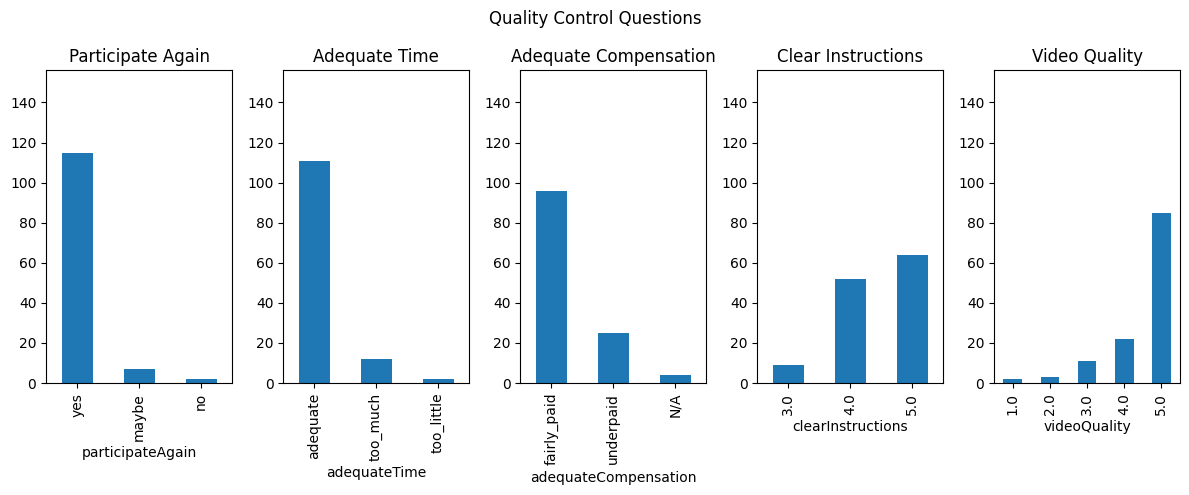

In [650]:
# [plot-qc]
# Plot QC data

plt.figure(figsize=(12, 5))
plt.subplot(1,5,1)
QC["participateAgain"].value_counts().plot(kind='bar', title="Participate Again")
plt.ylim(0, len(QC))

plt.subplot(1,5,2)
# QC["adequateTime"].value_counts().loc[["too_little", "adequate", "too_much"]].plot(kind='bar', title="Adequate Time")
QC["adequateTime"].value_counts().plot(kind='bar', title="Adequate Time")
plt.ylim(0, len(QC))

plt.subplot(1,5,3)
QC["adequateCompensation"].value_counts().plot(kind='bar', title="Adequate Compensation")
plt.ylim(0, len(QC))

plt.subplot(1,5,4)
QC["clearInstructions"].value_counts().sort_index().plot(kind='bar', title="Clear Instructions")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.subplot(1,5,5)
QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.suptitle("Quality Control Questions")
plt.tight_layout()

print("Comments:")
for i, row in all_data.iterrows():
        if len(str(row["textExpansion"])) > 5:
            print(row["gameId"], row["textExpansion"])
            


# QC

In [651]:
# [exclusions]
# Exclude groups that had trouble with audio/video or other communication issues based on feedback.

flagged_groups = [
    "ES0E4B", # Partner only was audio not video. Some communication barrier with language with my partner.
    "RHNS8Z", # Despite him not being able to hear me after the first round, we communicated well through gestures and facial expressions.
    "DA5DS8", # well my partner mention her mic wasnt working
    "WMJTSY"  # Obvious cheating
]

all_data = all_data[~all_data["gameId"].isin(flagged_groups)]


In [652]:
# [aggregate-to-groups]
# Our analysis is at the group level, so we need to aggregate the data to the gameId level. 
# We take the max time within each group, as the more externally-valid measure of completion.

data = all_data[[
    "treatment", "gameId", 
    "accuracy_1a", "accuracy_1b", "accuracy_1c", "accuracy_2", "accuracy_3", "accuracy_4", 
    "time_labeling_1a", "time_labeling_1b", "time_labeling_1c", "time_labeling_2", "time_labeling_3", "time_labeling_4"
]]
acc_cols = [col for col in data.columns if col.startswith("accuracy_")]
assert data.groupby(["treatment","gameId"])[acc_cols].std().max().max() == 0 # check accuracy identical within each gameId


# IMPORTANT: this is a per-column max within each (treatment, gameId) group
# (i.e., element-wise max across the two partner rows), NOT “pick the row with the max in some column”.
data = data.groupby(["treatment","gameId"]).max(numeric_only=True)

# recompute score based on max time for the group
data["score_1a"] = data["accuracy_1a"] / data["time_labeling_1a"] * 60  # correct labels per min
data["score_1b"] = data["accuracy_1b"] / data["time_labeling_1b"] * 60
data["score_1c"] = data["accuracy_1c"] / data["time_labeling_1c"] * 60
data["score_2"]  = data["accuracy_2"]  / data["time_labeling_2"]  * 60
data["score_3"]  = data["accuracy_3"]  / data["time_labeling_3"]  * 60
data["score_4"]  = data["accuracy_4"]  / data["time_labeling_4"]  * 60

print("Treatment counts with complete groups", data.groupby("treatment")["accuracy_1a"].count().to_dict())

data.reset_index(inplace=True)
data = data[data["treatment"].isin(["nonschema", "schema"])]

data.to_csv("study_1_analysis_ready.csv", index=False)  # per-game modeling table (post-exclusions)
data


Treatment counts with complete groups {'nonschema': 33, 'schema': 33}


,treatment,gameId,accuracy_1a,accuracy_1b,accuracy_1c,accuracy_2,accuracy_3,accuracy_4,time_labeling_1a,time_labeling_1b,time_labeling_1c,time_labeling_2,time_labeling_3,time_labeling_4,score_1a,score_1b,score_1c,score_2,score_3,score_4
0,nonschema,0NJX16,2.0,3.0,2.0,0.0,0.0,0.0,107.533,134.927,292.057,300.000,300.000,300.000,1.115937,1.334055,0.410879,0.000000,0.000000,0.000000
1,nonschema,14RBNC,2.0,4.0,8.0,8.0,6.0,7.0,95.275,128.718,141.991,192.847,236.068,191.411,1.259512,1.864541,3.380496,2.489020,1.524984,2.194231
2,nonschema,3NZWFJ,2.0,4.0,8.0,7.0,8.0,8.0,34.187,31.702,71.608,110.455,67.555,74.667,3.510106,7.570500,6.703162,3.802453,7.105322,6.428543
3,nonschema,3XTW7A,2.0,4.0,8.0,4.0,0.0,0.0,251.625,98.299,74.200,185.859,300.000,300.000,0.476900,2.441530,6.469003,1.291301,0.000000,0.000000
4,nonschema,407XTD,0.0,4.0,8.0,8.0,8.0,8.0,56.009,64.227,86.899,163.500,164.452,144.395,0.000000,3.736746,5.523654,2.935780,2.918785,3.324215
5,nonschema,4GBFHG,2.0,4.0,6.0,5.0,8.0,8.0,94.728,139.123,149.607,300.000,213.229,300.000,1.266785,1.725092,2.406305,1.000000,2.251101,1.600000
6,nonschema,57ZQA5,2.0,4.0,7.0,5.0,8.0,8.0,46.921,48.524,94.056,127.987,121.580,121.808,2.557490,4.946006,4.465425,2.343988,3.948018,3.940628
7,nonschema,868SK9,2.0,4.0,8.0,7.0,8.0,7.0,115.863,136.387,124.530,187.601,217.375,152.201,1.035706,1.759699,3.854493,2.238794,2.208166,2.759509
8,nonschema,987DM5,1.0,3.0,8.0,7.0,8.0,8.0,41.528,38.989,57.586,102.897,139.079,131.244,1.444808,4.616687,8.335359,4.081752,3.451276,3.657310
9,nonschema,9TJB6Q,1.0,4.0,7.0,4.0,0.0,0.0,150.385,120.743,180.157,300.000,300.000,300.000,0.398976,1.987693,2.331300,0.800000,0.000000,0.000000


## CONSORT participant flow

Dyad/participant counts at each exclusion step, rendered as a CONSORT-style
flow diagram (`figures/figureS4.pdf`). Self-contained: re-derives
the cascade from raw data so the numbers always match the `[load-data]` /
`[exclusions]` filters above.

CONSORT funnel: {'started': 215, 'not_consented': 5, 'no_intro': 46, 'no_partner': 8, 'randomized': {'part': 156, 'dyads': 79, 'schema': 39, 'nonschema': 40}, 'analyzed': {'part': 132, 'dyads': 66, 'schema': 33, 'nonschema': 33}}
Saved figures/figureS4.pdf and figures/figureS4.png


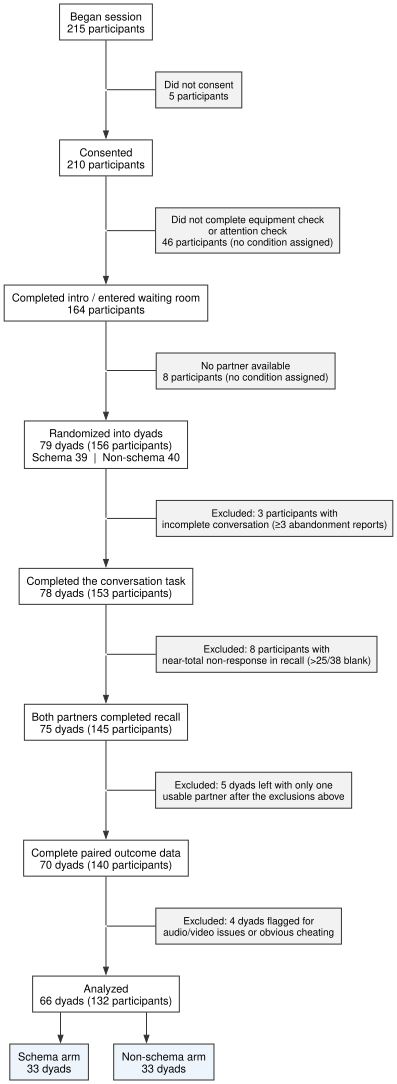

In [683]:
# [consort]
# CONSORT-style participant-flow diagram for Study 1. Self-contained: re-derives the
# enrollment funnel + exclusion cascade from raw data (prefixes vars with _ to avoid
# clobbering globals), then renders a vector PDF (+PNG) via analysis/consort.py.
# Mirrors the [load-data] / [exclusions] cells above; keep them in sync.
import glob as _glob, json as _json
from consort import consort_diagram

# Load ALL session records (including never-randomized ones) for the enrollment funnel.
_raw_all = []
for _fn in _glob.glob("../data/study_1_schema_nonschema/batch_*.scienceData.jsonl"):
    for _line in open(_fn):
        _raw_all.append(_json.loads(_line))
_raw = [r for r in _raw_all if r["sampleId"] != "missing"]  # randomized into a dyad

# Enrollment funnel (pre-randomization). Never-randomized records have sampleId=="missing",
# no gameId, and treatment=="missing"; consent is a list of agreed items when given.
# playerIntroDone is set when a participant finishes the intro sequence (equipment
# check, attention check, instructions) and enters the waiting room; absence means
# they dropped during intro. gameStarted is never set for unmatched participants.
_started = len(_raw_all)
_not_consented = sum(1 for r in _raw_all if not isinstance(r.get("consent"), list))
_unmatched = [r for r in _raw_all
              if isinstance(r.get("consent"), list) and r.get("sampleId") == "missing"]
def _intro_done(r):
    return r.get("times", {}).get("playerIntroDone", "missing") != "missing"
_no_intro = sum(1 for r in _unmatched if not _intro_done(r))   # dropped during intro
_no_partner = sum(1 for r in _unmatched if _intro_done(r))     # completed intro, never matched
_consented = _started - _not_consented
_entered_lobby = _consented - _no_intro
assert _started == _not_consented + _no_intro + _no_partner + len(_raw)

_d = pd.DataFrame({
    "treatment": [r["treatment"]["name"] for r in _raw],
    "gameId": [r["gameId"][-6:] for r in _raw],
    "num_reports": [len(r["reports"]) for r in _raw],
})
_rcl = pd.DataFrame([{k: v["value"].lower().strip()
                      for k, v in r["prompts"].items() if "recall" in k} for r in _raw])
_rcl.columns = [c.replace("prompt_recall_", "recall_") for c in _rcl.columns]
_rcl = _rcl[sorted(_rcl.columns)].fillna("")
_d = pd.concat([_d.reset_index(drop=True), _rcl.reset_index(drop=True)], axis=1)

# recompute per-round accuracy (needed for the pair-complete filter)
_m = (_d.groupby("gameId")[_rcl.columns].nunique() == 1) & (_d.groupby("gameId")[_rcl.columns].count() == 2)
_m.columns = [c.replace("recall_", "match_") for c in _m.columns]
_d = pd.merge(_d, _m, left_on="gameId", right_index=True)
for _mc in [c for c in _d.columns if c.startswith("match_")]:
    _d[_mc.replace("match_", "matched_recall_")] = _d[_mc.replace("match_", "recall_")] * _d[_mc]
for _rd in ["3", "4"]:
    _cols = [c for c in _d.columns if f"matched_recall_{_rd}_" in c]
    _d[f"accuracy_{_rd}"] = _d[_cols].replace("", np.nan).nunique(axis=1).astype(float)

_FLAGGED = ["ES0E4B", "RHNS8Z", "DA5DS8", "WMJTSY"]  # mirrors the [exclusions] cell

def _counts(x):
    return dict(part=len(x), dyads=x.gameId.nunique(),
                schema=x[x.treatment == "schema"].gameId.nunique(),
                nonschema=x[x.treatment == "nonschema"].gameId.nunique())

# --- exclusion cascade (same order/criteria as [load-data] + [exclusions]) ---
_s0 = _counts(_d)                                                            # randomized
_x = _d[_d["num_reports"] < 3].copy()
_s1 = _counts(_x)                                                            # completed conversation
_x["_blank"] = (_x[_rcl.columns] == "").sum(axis=1)
_x = _x[_x["_blank"] < 26]
_s2 = _counts(_x)                                                            # both partners did recall
_pc = (_x.groupby("gameId")[["accuracy_3", "accuracy_4"]].count() == 2).all(axis=1)
_x = _x[_x.gameId.isin(_pc[_pc].index)]
_s3 = _counts(_x)                                                            # complete paired outcomes
_x = _x[~_x.gameId.isin(_FLAGGED)]
_s4 = _counts(_x)                                                            # analyzed

# guard: final cascade count must match the analyzed `data` table built above
assert _s4["dyads"] == data["gameId"].nunique(), "CONSORT total != analyzed sample"
print("CONSORT funnel:", {"started": _started, "not_consented": _not_consented,
                          "no_intro": _no_intro, "no_partner": _no_partner,
                          "randomized": _s0, "analyzed": _s4})

_stages = [
    f"Began session\n{_started} participants",
    f"Consented\n{_consented} participants",
    f"Completed intro / entered waiting room\n{_entered_lobby} participants",
    f"Randomized into dyads\n{_s0['dyads']} dyads ({_s0['part']} participants)\n"
    f"Schema {_s0['schema']}  |  Non-schema {_s0['nonschema']}",
    f"Completed the conversation task\n{_s1['dyads']} dyads ({_s1['part']} participants)",
    f"Both partners completed recall\n{_s2['dyads']} dyads ({_s2['part']} participants)",
    f"Complete paired outcome data\n{_s3['dyads']} dyads ({_s3['part']} participants)",
    f"Analyzed\n{_s4['dyads']} dyads ({_s4['part']} participants)",
]
_exclusions = [
    f"Did not consent\n{_not_consented} participants",
    f"Did not complete equipment check\nor attention check\n"
    f"{_no_intro} participants (no condition assigned)",
    f"No partner available\n{_no_partner} participants (no condition assigned)",
    f"Excluded: {_s0['part'] - _s1['part']} participants with\nincomplete conversation "
    f"(≥3 abandonment reports)",
    f"Excluded: {_s1['part'] - _s2['part']} participants with\nnear-total non-response in "
    f"recall (>25/38 blank)",
    f"Excluded: {_s2['dyads'] - _s3['dyads']} dyads left with only one\nusable partner after the exclusions above",
    f"Excluded: {_s3['dyads'] - _s4['dyads']} dyads flagged for\naudio/video issues or "
    f"obvious cheating",
]
_arms = [f"Schema arm\n{_s4['schema']} dyads", f"Non-schema arm\n{_s4['nonschema']} dyads"]

consort_diagram(_stages, _exclusions, _arms, path="figures/figureS4")


## Sample description (demographics)

Demographic summary of the analyzed sample, from the Demographics exit survey (retained in the released data). Education uses the `@watts-lab/surveys` coding; "bachelor's degree or higher" = codes 6–8 in both the US and UK scales. Education was only asked of US and UK residents, so it is summarized over the subset who answered.

In [654]:
# [demographics]
# Sample description for the analyzed sample (the participants in the final
# group-level `data`). Reads the Demographics exit survey from the released data.
# Education coding (@watts-lab/surveys): bachelor's or higher = codes 6,7,8 in BOTH
# the US and UK scales. Education is only asked of US/UK residents, so it is
# summarized over those who answered.
REF_YEAR = 2026
DEGREE_CODES = {"6", "7", "8"}

# demographics keyed by sampleId, parsed from the raw records
demographics = {}
for row in raw:
    for k, v in row.get("surveys", {}).items():
        if "Demographics" in k and isinstance(v, dict):
            demographics[row["sampleId"]] = v.get("responses") or {}

# restrict to the analyzed sample (participants whose group survived exclusions)
analyzed = all_data[all_data["gameId"].isin(data["gameId"])]
sample = [demographics.get(sid, {}) for sid in analyzed["sampleId"]]
n = len(sample)

gender = [d.get("gender") for d in sample if d.get("gender")]
n_female = sum(g == "female" for g in gender)

ages = np.array([REF_YEAR - int(d["birth_year"]) for d in sample
                 if str(d.get("birth_year", "")).isdigit()
                 and 1920 <= int(d["birth_year"]) <= REF_YEAR - 13], dtype=float)

edu = [d for d in sample if d.get("education_US") or d.get("education_UK")]
n_bachelor = sum((d.get("education_US") in DEGREE_CODES) or (d.get("education_UK") in DEGREE_CODES)
                 for d in edu)

print(f"Analyzed sample: N = {n} participants ({analyzed['gameId'].nunique()} groups)")
print(f"  Female: {n_female}/{len(gender)} = {100 * n_female / len(gender):.1f}%  (of those reporting gender)")
print(f"  Age:    mean {ages.mean():.1f}, SD {ages.std(ddof=1):.1f}  (n = {len(ages)})")
print(f"  Education reported (US/UK residents): {len(edu)}/{n} ({100 * len(edu) / n:.0f}% of sample)")
print(f"    Bachelor's degree or higher: {n_bachelor}/{len(edu)} = {100 * n_bachelor / len(edu):.1f}% (of those reporting)")


Analyzed sample: N = 132 participants (66 groups)
  Female: 57/130 = 43.8%  (of those reporting gender)
  Age:    mean 39.9, SD 13.5  (n = 130)
  Education reported (US/UK residents): 80/132 (61% of sample)
    Bachelor's degree or higher: 55/80 = 68.8% (of those reporting)


In [655]:
# [export-text-data]
# Export labeling and recall text data for groups that survive quality checks
label_cols = [col for col in all_data.columns if col.startswith("labeling_")]
recall_cols = [col for col in all_data.columns if col.startswith("recall_")]

text_data = all_data[all_data["gameId"].isin(data["gameId"])][
    ["gameId", "treatment", "position"] + label_cols + recall_cols
].sort_values(by=["treatment", "gameId", "position"])

# text responses are included in study_1_participant_data.csv (labeling_*/recall_*); redundant export removed
print(f"Exported {len(text_data)} rows, {len(text_data.columns)} columns")
text_data.head()

Exported 132 rows, 47 columns


,gameId,treatment,position,labeling_1a,labeling_1b,labeling_1c,labeling_2,labeling_3,labeling_4,recall_1a_0,...,recall_3_6,recall_3_7,recall_4_0,recall_4_1,recall_4_2,recall_4_3,recall_4_4,recall_4_5,recall_4_6,recall_4_7
48,0NJX16,nonschema,0,Image 1:kada\nImage 2:kuda,Image 1:ele\nImage 2:elo\nImage 3:eli\nImage 4:ede,Image 1:aa\nImage 2:bb\nImage 3:cc\nImage 4:dd\nImage 5:ee\nImage 6:ff\nImage 7:gg\nImage 8:hh,Image 1:ch\nImage 2:cg\nImage 3:cc\nImage 4:cd\nImage 5:ca\nImage 6:ce\nImage 7:cb\nImage 8:cf,Image 1:df\nImage 2:db\nImage 3:dg\nImage 4:dh\nImage 5:dd\nImage 6:da\nImage 7:de\nImage 8:dc,Image 1:ed\nImage 2:ea\nImage 3:ef\nImage 4:eh\nImage 5:ec\nImage 6:eb\nImage 7:eg\nImage 8:ef,kuda,...,,,,,,,,,,
40,0NJX16,nonschema,1,Image 1:kada\nImage 2:kuda,Image 1:ele\nImage 2:elo\nImage 3:eli\nImage 4:ede,Image 1:aa\nImage 2:bb\nImage 3:cc\nImage 4:dd\nImage 5:ee\nImage 6:ff\nImage 7:gg\nImage 8:hh,Image 1:ch\nImage 2:cg\nImage 3:cc\nImage 4:cd\nImage 5:ca\nImage 6:ce\nImage 7:cb\nImage 8:cf,Image 1:df\nImage 2:db\nImage 3:dg\nImage 4:dh\nImage 5:dd\nImage 6:da\nImage 7:de\nImage 8:dc,Image 1:ed\nImage 2:ea\nImage 3:ef\nImage 4:eh\nImage 5:ec\nImage 6:eb\nImage 7:eg\nImage 8:ef,kuda,...,df,da,eh,ea,ef,ed,ec,ea,ef,eg
63,14RBNC,nonschema,0,Image 1: owl \nImage 2: cookie,Image 1: batman\nImage 2:waffle\nImage 3:et\nImage 4:train,Image 1:owl\nImage 2:scorpion\nImage 3:dog\nImage 4:train\nImage 5:cookie\nImage 6:crab\nImage 7:telephone\nImage 8:et,Image 1:rainbow\nImage 2:paper\nImage 3:waiter\nImage 4:tree\nImage 5:seesaw\nImage 6:clown\nImage 7:telescope\nImage 8:oven,Image 1:rainbow\nImage 2:waiter\nImage 3:trashcan\nImage 4:parrot\nImage 5:rotor\nImage 6:crab\nImage 7:spongebob\nImage 8:lobster,Image 1:grill\nImage 2:bee\nImage 3:cheese\nImage 4:milk man \nImage 5:baby\nImage 6:sausage \nImage 7:gum\nImage 8:chocolate,cookie,...,rainbow,waiter,gum,bee,cheese,chocolate,grill,sausage,baby,milk man
62,14RBNC,nonschema,1,Image 1: owl \nImage 2: cookie,Image 1: batman\nImage 2:waffle\nImage 3:et\nImage 4:train,Image 1:owl\nImage 2:scorpion\nImage 3:dog\nImage 4:train\nImage 5:cookie\nImage 6:crab\nImage 7:telephone\nImage 8:et,Image 1:rainbow\nImage 2:paper\nImage 3:waiter\nImage 4:tree\nImage 5:seesaw\nImage 6:clown\nImage 7:telescope\nImage 8:oven,Image 1:rainbow\nImage 2:waiter\nImage 3:trashcan\nImage 4:parrot\nImage 5:rotor\nImage 6:crab\nImage 7:spongebob\nImage 8:lobster,Image 1:grill\nImage 2:bee\nImage 3:cheese\nImage 4:milk man \nImage 5:baby\nImage 6:sausage \nImage 7:gum\nImage 8:chocolate,cookie,...,rainbow,waiter,gum,bee,cheese,chocolate,grill,sausage,baby,milkman
105,3NZWFJ,nonschema,0,Image 1: Bird\nImage 2: Biscuit,Image 1: bird\nImage 2: biscuit\nImage 3: binoculars\nImage 4: gascan,Image 1: bird\nImage 2: scorpion\nImage 3: pig\nImage 4: gascan\nImage 5: biscuit\nImage 6: mower\nImage 7: mushroom\nImage 8: binoculars,Image 1: peacock\nImage 2: tofu\nImage 3: foot\nImage 4: tree\nImage 5: binoculars\nImage 6: can\nImage 7: switch\nImage 8: yellow,Image 1: rainbow\nImage 2: binoculars\nImage 3: grey\nImage 4: bird\nImage 5: wheel\nImage 6: white\nImage 7: yellow\nImage 8: red,Image 1: blue\nImage 2: gum\nImage 3: yellow\nImage 4: white\nImage 5: cream\nImage 6: black\nImage 7: purple\nImage 8: brown,biscuit,...,rainbow,binoculars,purple,gum,yellow,brown,blue,black,cream,white


# Analysis

In [656]:
# [sanity-check-means]
# Quick look for sanity checking
data.groupby("treatment")[["accuracy_3", "accuracy_4", "time_labeling_3", "time_labeling_4", "score_3", "score_4"]].mean().loc[['nonschema', 'schema']]

,accuracy_3,accuracy_4,time_labeling_3,time_labeling_4,score_3,score_4
treatment,,,,,,
nonschema,6.696970,6.545455,183.247364,176.963182,2.648491,2.647041
schema,7.393939,5.212121,115.087424,223.372091,5.864810,1.852432


In [657]:
# [prereg-h1-r3-time]
# === Preregistered Primary Analyses ===
# H1: Round 3 labeling time (max per group), one-tailed Welch's t-test (Schema < Nonschema)
# H2b: Round 4 accuracy (unique matched recall), one-tailed Mann–Whitney U (Schema < Nonschema)

# Prepare data for H1, H2a, and H2b
schema = data[data["treatment"] == "schema"]
nonschema = data[data["treatment"] == "nonschema"]

# H1: Round 3 labeling time (max per group)
schema_time3 = schema["time_labeling_3"].values
nonschema_time3 = nonschema["time_labeling_3"].values

t_stat, p_val = stats.ttest_ind(schema_time3, nonschema_time3, equal_var=False, alternative="less")
mean_diff = schema_time3.mean() - nonschema_time3.mean()
ci = stats.t.interval(
    0.95, 
    df=min(len(schema_time3), len(nonschema_time3))-1, 
    loc=mean_diff, 
    scale=np.sqrt(schema_time3.var(ddof=1)/len(schema_time3) + nonschema_time3.var(ddof=1)/len(nonschema_time3))
)
pooled_sd = np.sqrt(((len(schema_time3)-1)*schema_time3.var(ddof=1) + (len(nonschema_time3)-1)*nonschema_time3.var(ddof=1)) / (len(schema_time3)+len(nonschema_time3)-2))
cohens_d = mean_diff / pooled_sd

print("="*60)
print("H1: Round 3 Labeling Time (max per group)")
print("="*60)
print(f"Schema n={len(schema_time3)}, mean={schema_time3.mean():.2f}, sd={schema_time3.std(ddof=1):.2f}")
print(f"Nonschema n={len(nonschema_time3)}, mean={nonschema_time3.mean():.2f}, sd={nonschema_time3.std(ddof=1):.2f}")
print(f"Mean difference (Schema - Nonschema): {mean_diff:.2f} sec")
print(f"95% CI for mean difference: [{ci[0]:.2f}, {ci[1]:.2f}]")  # TODO: make the CI calculation one-sided to match the t-test
print(f"Welch's t-test (one-tailed, Schema < Nonschema): t={t_stat:.3f}, p={p_val:.5f}")
print(f"Cohen's d: {cohens_d:.3f}\n")

H1: Round 3 Labeling Time (max per group)
Schema n=33, mean=115.09, sd=62.04
Nonschema n=33, mean=183.25, sd=64.15
Mean difference (Schema - Nonschema): -68.16 sec
95% CI for mean difference: [-99.80, -36.52]
Welch's t-test (one-tailed, Schema < Nonschema): t=-4.387, p=0.00002
Cohen's d: -1.080



In [658]:
# [h2a-time-attenuation]
# === H2a: Attenuation of labeling time advantage ===
# H2a predicted that the Schema group's labeling time advantage would attenuate
# under schema-destroying change (Round 4). The preregistration did not specify
# a statistical test. We operationalize this as a difference-in-differences:
#   ΔT = time_labeling_4 - time_labeling_3  (within-group change)
# and test whether Schema groups' ΔT is greater than Non-schema groups' ΔT
# (i.e., schema groups get relatively slower), one-tailed Welch's t-test.

schema_time4 = schema["time_labeling_4"].values
nonschema_time4 = nonschema["time_labeling_4"].values

schema_delta = schema_time4 - schema_time3        # change in labeling time R3→R4
nonschema_delta = nonschema_time4 - nonschema_time3

# One-tailed Welch's t: Schema ΔT > Nonschema ΔT (schema gets relatively slower)
h2a_t, h2a_p = stats.ttest_ind(schema_delta, nonschema_delta, equal_var=False, alternative="greater")
h2a_mean_diff = schema_delta.mean() - nonschema_delta.mean()

# Welch-Satterthwaite df and 95% CI
n1_h2a, n2_h2a = len(schema_delta), len(nonschema_delta)
s1_h2a, s2_h2a = schema_delta.var(ddof=1), nonschema_delta.var(ddof=1)
se_h2a = np.sqrt(s1_h2a / n1_h2a + s2_h2a / n2_h2a)
df_h2a = (s1_h2a / n1_h2a + s2_h2a / n2_h2a) ** 2 / (
    (s1_h2a / n1_h2a) ** 2 / (n1_h2a - 1) + (s2_h2a / n2_h2a) ** 2 / (n2_h2a - 1)
)
t_crit_h2a = stats.t.ppf(0.975, df=df_h2a)
h2a_ci = (h2a_mean_diff - t_crit_h2a * se_h2a, h2a_mean_diff + t_crit_h2a * se_h2a)

pooled_sd_h2a = np.sqrt(
    ((n1_h2a - 1) * s1_h2a + (n2_h2a - 1) * s2_h2a) / (n1_h2a + n2_h2a - 2)
)
h2a_d = h2a_mean_diff / pooled_sd_h2a

print("=" * 60)
print("H2a: Attenuation of labeling time advantage (R3 → R4)")
print("=" * 60)
print(f"Schema ΔT (R4−R3):    n={n1_h2a}, mean={schema_delta.mean():.2f}s, sd={schema_delta.std(ddof=1):.2f}")
print(f"Nonschema ΔT (R4−R3): n={n2_h2a}, mean={nonschema_delta.mean():.2f}s, sd={nonschema_delta.std(ddof=1):.2f}")
print(f"Mean difference in ΔT (Schema − Nonschema): {h2a_mean_diff:.2f}s")
print(f"95% CI: [{h2a_ci[0]:.2f}, {h2a_ci[1]:.2f}]")
print(f"Welch's t (one-tailed, Schema ΔT > Nonschema ΔT): t={h2a_t:.3f}, p={h2a_p:.5f}")
print(f"Cohen's d: {h2a_d:.3f}")

H2a: Attenuation of labeling time advantage (R3 → R4)
Schema ΔT (R4−R3):    n=33, mean=108.28s, sd=92.21
Nonschema ΔT (R4−R3): n=33, mean=-6.28s, sd=44.16
Mean difference in ΔT (Schema − Nonschema): 114.57s
95% CI: [78.74, 150.39]
Welch's t (one-tailed, Schema ΔT > Nonschema ΔT): t=6.438, p=0.00000
Cohen's d: 1.585


In [659]:
# [r4-time]
# === Round 4 labeling time (Schema vs Non-schema, direct) ===
# Companion to H2b (R4 accuracy). H2a shows the Schema time advantage attenuates
# R3->R4; this tests whether it actually REVERSES at R4: are Schema groups slower
# than Non-schema once the schema is broken? One-tailed Welch's t (Schema > Nonschema).
# (Reuses schema_time4 / nonschema_time4 from the H2a cell.)
r4t_t, r4t_p = stats.ttest_ind(schema_time4, nonschema_time4, equal_var=False, alternative="greater")
r4t_p_two = stats.ttest_ind(schema_time4, nonschema_time4, equal_var=False, alternative="two-sided")[1]
r4t_diff = schema_time4.mean() - nonschema_time4.mean()
n1, n2 = len(schema_time4), len(nonschema_time4)
s1, s2 = schema_time4.var(ddof=1), nonschema_time4.var(ddof=1)
se = np.sqrt(s1 / n1 + s2 / n2)
df_r4t = (s1 / n1 + s2 / n2) ** 2 / ((s1 / n1) ** 2 / (n1 - 1) + (s2 / n2) ** 2 / (n2 - 1))
t_crit = stats.t.ppf(0.975, df=df_r4t)
r4t_ci = (r4t_diff - t_crit * se, r4t_diff + t_crit * se)
pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
r4t_d = r4t_diff / pooled

print("=" * 60)
print("Round 4 labeling time (Schema vs Non-schema, direct)")
print("=" * 60)
print(f"Schema    n={n1}, mean={schema_time4.mean():.2f}s, sd={schema_time4.std(ddof=1):.2f}")
print(f"Nonschema n={n2}, mean={nonschema_time4.mean():.2f}s, sd={nonschema_time4.std(ddof=1):.2f}")
print(f"Mean difference (Schema - Nonschema): {r4t_diff:.2f} sec")
print(f"95% CI for mean difference (Welch-Satterthwaite): [{r4t_ci[0]:.2f}, {r4t_ci[1]:.2f}]")
print(f"Welch's t-test: t={r4t_t:.3f}")
print(f"  one-tailed (Schema > Nonschema): p={r4t_p:.5f}")
print(f"  two-tailed:                      p={r4t_p_two:.5f}")
print(f"Cohen's d: {r4t_d:.3f}")


Round 4 labeling time (Schema vs Non-schema, direct)
Schema    n=33, mean=223.37s, sd=82.19
Nonschema n=33, mean=176.96s, sd=63.26
Mean difference (Schema - Nonschema): 46.41 sec
95% CI for mean difference (Welch-Satterthwaite): [10.30, 82.52]
Welch's t-test: t=2.571
  one-tailed (Schema > Nonschema): p=0.00633
  two-tailed:                      p=0.01265
Cohen's d: 0.633


In [660]:
# [prereg-h2b-r4-accuracy]
# H2b: Round 4 accuracy — all preregistered reported quantities
# Group medians, Hodges-Lehmann estimate with 95% CI,
# Cliff's delta, and permutation-based one-sided Mann-Whitney U p-value.

np.random.seed(42)

schema_points4 = schema["accuracy_4"].values
nonschema_points4 = nonschema["accuracy_4"].values

# Group means and medians
schema_mean4 = np.mean(schema_points4)
nonschema_mean4 = np.mean(nonschema_points4)
schema_median4 = np.median(schema_points4)
nonschema_median4 = np.median(nonschema_points4)

# Hodges-Lehmann estimate and 95% bootstrap CI
pairwise_diffs = schema_points4[:, np.newaxis] - nonschema_points4
hl_estimate = np.median(pairwise_diffs)

n_bootstrap = 9999
boot_hl = []
for _ in range(n_bootstrap):
    b_schema = np.random.choice(schema_points4, len(schema_points4), replace=True)
    b_nonschema = np.random.choice(nonschema_points4, len(nonschema_points4), replace=True)
    boot_hl.append(np.median(b_schema[:, np.newaxis] - b_nonschema))
hl_ci = np.percentile(boot_hl, [2.5, 97.5])

# Cliff's delta
def cliffs_delta(x, y):
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, np.newaxis] > y)
    less = np.sum(x[:, np.newaxis] < y)
    return (greater - less) / (n1 * n2)

cliff_d = cliffs_delta(schema_points4, nonschema_points4)

# Permutation-based Mann-Whitney U p-value
observed_u, _ = stats.mannwhitneyu(schema_points4, nonschema_points4, alternative='less')
combined = np.concatenate([schema_points4, nonschema_points4])
n_schema = len(schema_points4)

perm_u_stats = np.array([
    stats.mannwhitneyu(
        (perm := np.random.permutation(combined))[:n_schema],
        perm[n_schema:],
        alternative='less'
    ).statistic
    for _ in range(9999)
])
p_perm = (np.sum(perm_u_stats <= observed_u) + 1) / (9999 + 1)

# Report
print("=" * 60)
print("H2b: Round 4 Accuracy (# correct out of 8)")
print("=" * 60)
print(f"Schema:    n={len(schema_points4)}, mean={schema_mean4:.2f}, median={schema_median4:.1f}")
print(f"Nonschema: n={len(nonschema_points4)}, mean={nonschema_mean4:.2f}, median={nonschema_median4:.1f}")
print(f"Hodges-Lehmann estimate (Schema − Nonschema): {hl_estimate:.2f}")
print(f"95% bootstrap CI: [{hl_ci[0]:.2f}, {hl_ci[1]:.2f}]")
print(f"Cliff's delta: {cliff_d:.3f}")
print(f"Mann-Whitney U (one-tailed, Schema < Nonschema): U={observed_u:.1f}, p={p_perm:.4f}")
print(f"(permutation-based, 9999 permutations, seed=42)")

H2b: Round 4 Accuracy (# correct out of 8)
Schema:    n=33, mean=5.21, median=6.0
Nonschema: n=33, mean=6.55, median=7.0
Hodges-Lehmann estimate (Schema − Nonschema): -1.00
95% bootstrap CI: [-3.00, 0.00]
Cliff's delta: -0.381
Mann-Whitney U (one-tailed, Schema < Nonschema): U=337.0, p=0.0027
(permutation-based, 9999 permutations, seed=42)


In [661]:
# [r3-accuracy]
# === Round 3 accuracy (Schema vs Non-schema) ===
# We test whether accuracy differs between conditions in Round 3
# (schema-conserving change) using the same Mann-Whitney U framework as H2b,
# but two-tailed since we have no directional prediction.

np.random.seed(42)

schema_points3 = schema["accuracy_3"].values
nonschema_points3 = nonschema["accuracy_3"].values

# Group means and medians
schema_mean3 = np.mean(schema_points3)
nonschema_mean3 = np.mean(nonschema_points3)
schema_median3 = np.median(schema_points3)
nonschema_median3 = np.median(nonschema_points3)

# Hodges-Lehmann estimate and 95% bootstrap CI
pairwise_diffs_3 = schema_points3[:, np.newaxis] - nonschema_points3
hl_estimate_3 = np.median(pairwise_diffs_3)

n_bootstrap = 9999
boot_hl_3 = []
for _ in range(n_bootstrap):
    b_schema = np.random.choice(schema_points3, len(schema_points3), replace=True)
    b_nonschema = np.random.choice(nonschema_points3, len(nonschema_points3), replace=True)
    boot_hl_3.append(np.median(b_schema[:, np.newaxis] - b_nonschema))
hl_ci_3 = np.percentile(boot_hl_3, [2.5, 97.5])

# Cliff's delta
cliff_d_3 = cliffs_delta(schema_points3, nonschema_points3)

# Permutation-based Mann-Whitney U p-value (two-tailed)
observed_u_3, _ = stats.mannwhitneyu(schema_points3, nonschema_points3, alternative='two-sided')
combined_3 = np.concatenate([schema_points3, nonschema_points3])
n_schema_3 = len(schema_points3)

perm_u_stats_3 = np.array([
    stats.mannwhitneyu(
        (perm := np.random.permutation(combined_3))[:n_schema_3],
        perm[n_schema_3:],
        alternative='two-sided'
    ).statistic
    for _ in range(9999)
])
p_perm_3 = (np.sum(perm_u_stats_3 >= observed_u_3) + 1) / (9999 + 1)

# Report
print("=" * 60)
print("Round 3 Accuracy (# correct out of 8)")
print("=" * 60)
print(f"Schema:    n={len(schema_points3)}, mean={schema_mean3:.2f}, median={schema_median3:.1f}")
print(f"Nonschema: n={len(nonschema_points3)}, mean={nonschema_mean3:.2f}, median={nonschema_median3:.1f}")
print(f"Hodges-Lehmann estimate (Schema \u2212 Nonschema): {hl_estimate_3:.2f}")
print(f"95% bootstrap CI: [{hl_ci_3[0]:.2f}, {hl_ci_3[1]:.2f}]")
print(f"Cliff\u2019s delta: {cliff_d_3:.3f}")
print(f"Mann-Whitney U (two-tailed): U={observed_u_3:.1f}, p={p_perm_3:.4f}")
print(f"(permutation-based, 9999 permutations, seed=42)")

Round 3 Accuracy (# correct out of 8)
Schema:    n=33, mean=7.39, median=8.0
Nonschema: n=33, mean=6.70, median=8.0
Hodges-Lehmann estimate (Schema − Nonschema): 0.00
95% bootstrap CI: [0.00, 1.00]
Cliff’s delta: 0.152
Mann-Whitney U (two-tailed): U=627.0, p=0.1044
(permutation-based, 9999 permutations, seed=42)


2. BOOTSTRAP CI FOR MEAN DIFFERENCE (Round 4 Accuracy)
Mean difference (schema - nonschema): -1.33
95% Bootstrap CI: [-2.39, -0.24]
CI includes 0? False



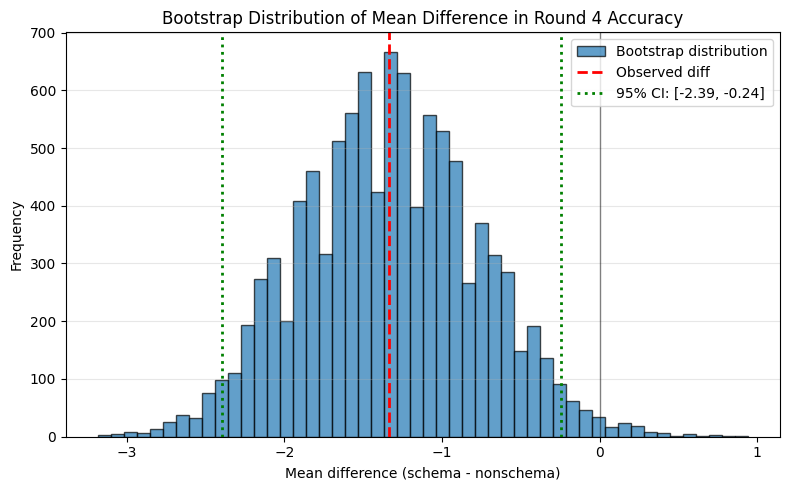

In [662]:
# [bootstrap-ci-r4]
# 2. BOOTSTRAP CI FOR MEAN DIFFERENCE (nonparametric, 95% CI)
# Resample pairs within each treatment; compute difference in means

def bootstrap_ci(group1, group2, n_bootstrap=10000, ci=95):
    """
    Bootstrap CI for difference in means (group1 - group2).
    Resamples independently within each group.
    """
    alpha_level = (100 - ci) / 2
    boot_diffs = []
    np.random.seed(42)
    
    for _ in range(n_bootstrap):
        boot_g1 = np.random.choice(group1, size=len(group1), replace=True)
        boot_g2 = np.random.choice(group2, size=len(group2), replace=True)
        boot_diffs.append(boot_g1.mean() - boot_g2.mean())
    
    boot_diffs = np.array(boot_diffs)
    ci_lower = np.percentile(boot_diffs, alpha_level)
    ci_upper = np.percentile(boot_diffs, 100 - alpha_level)
    
    return boot_diffs, ci_lower, ci_upper

boot_diffs, ci_lower, ci_upper = bootstrap_ci(
    schema_points4, nonschema_points4, n_bootstrap=10000, ci=95
)

print("=" * 60)
print("2. BOOTSTRAP CI FOR MEAN DIFFERENCE (Round 4 Accuracy)")
print("=" * 60)
print(f"Mean difference (schema - nonschema): {schema_points4.mean() - nonschema_points4.mean():.2f}")
print(f"95% Bootstrap CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"CI includes 0? {ci_lower <= 0 <= ci_upper}\n")

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_diffs, bins=50, alpha=0.7, edgecolor='black', label='Bootstrap distribution')
ax.axvline(schema_points4.mean() - nonschema_points4.mean(), color='red', linestyle='--', linewidth=2, label='Observed diff')
ax.axvline(ci_lower, color='green', linestyle=':', linewidth=2, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
ax.axvline(ci_upper, color='green', linestyle=':', linewidth=2)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('Mean difference (schema - nonschema)')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Mean Difference in Round 4 Accuracy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


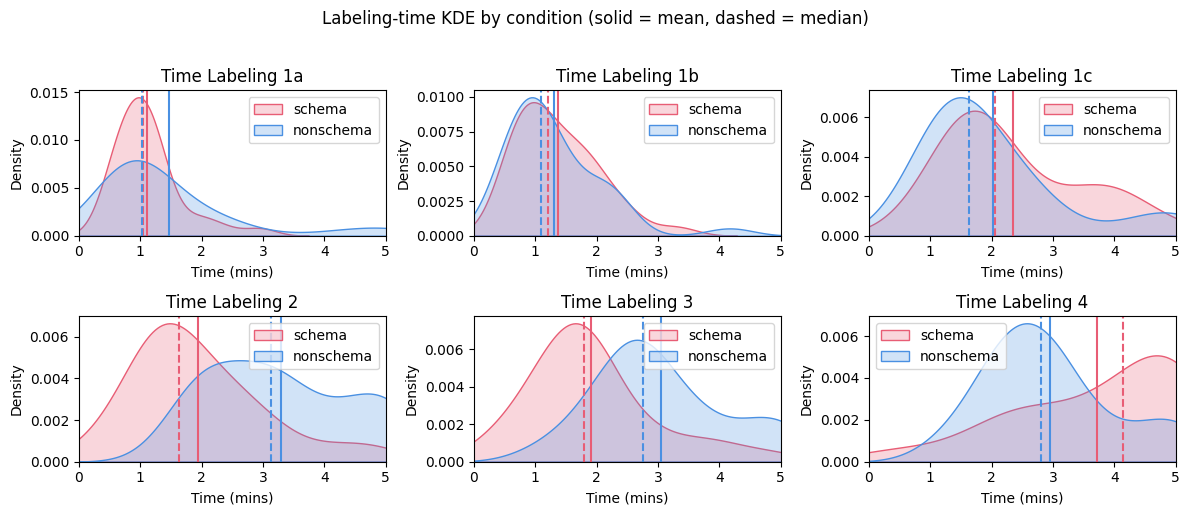

In [663]:
# [fig-time-kde]
# KDE of completion times by stage and treatment, with the true (data) mean and
# median of each condition marked: solid line = mean, dashed line = median.
color_map = {"schema": "#E85D75", "nonschema": "#4A90E2"}
plt.figure(figsize=(12, 5))
for i, stage in enumerate(["1a", "1b", "1c", "2", "3", "4"]):
    ax = plt.subplot(2, 3, i + 1)
    for treatment in ["schema", "nonschema"]:
        vals = data[data["treatment"] == treatment][f"time_labeling_{stage}"].dropna()
        c = color_map[treatment]
        sns.kdeplot(vals, label=treatment, fill=True, color=c, ax=ax)
        ax.axvline(vals.mean(),   color=c, linestyle="-",  linewidth=1.5)
        ax.axvline(vals.median(), color=c, linestyle="--", linewidth=1.5)
    ax.set_title(f"Time Labeling {stage}")
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("Density")
    ax.set_xticks(range(0, 330, 60))
    ax.set_xticklabels(range(0, 6, 1))
    ax.set_xlim(0, 300)
    ax.legend()
plt.suptitle("Labeling-time KDE by condition (solid = mean, dashed = median)", y=1.02)
plt.tight_layout()


# Plots

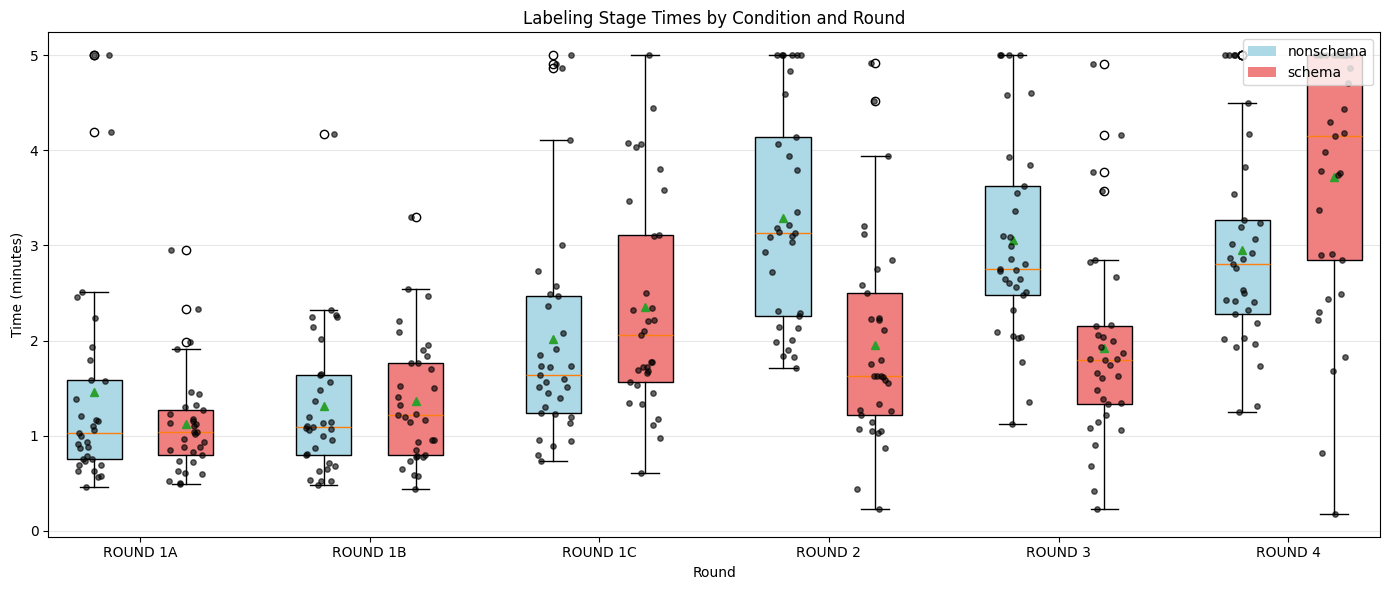

In [664]:
# [fig-time-box]
labeling_stage_time_cols = [col for col in data.columns if col.startswith("time_labeling_")]


# Prepare data for box plot
# Melt the data to long format for easier plotting
plot_data = []
for col in labeling_stage_time_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'time': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = labeling_stage_time_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'labeling_1a' to 'Round 1a', etc.
    return col_name.replace('time_labeling_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['time'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('Time (minutes)')
ax.set_title('Labeling Stage Times by Condition and Round')
ax.grid(axis='y', alpha=0.3)

# # Add n labels above each box
# n_counts = plot_df.groupby(['round', 'condition']).count()['time']
# for i, round_name in enumerate(rounds):
#     for j, condition in enumerate(conditions):
#         n = n_counts.get((round_name, condition), 0)
#         pos = i * (len(conditions) + 0.5) + j
#         y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
#         ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)

ax.set_yticks(range(0, 310, 60))
ax.set_yticklabels(range(0, 6, 1))

plt.tight_layout()
plt.show()

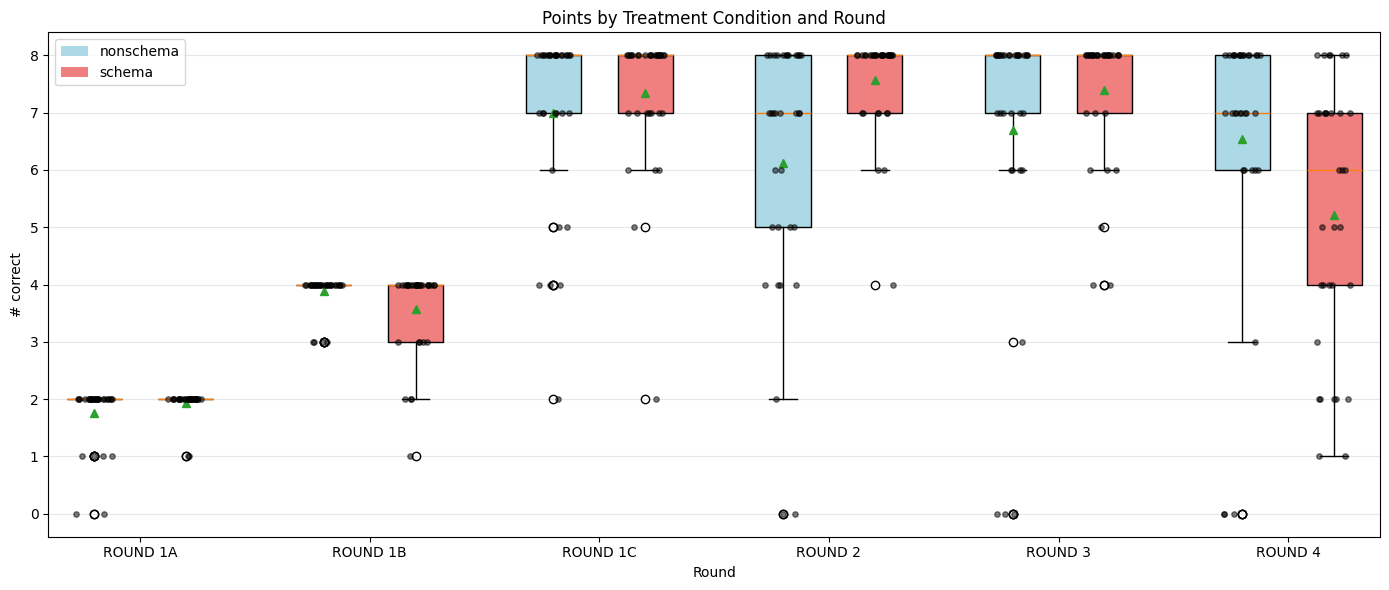

In [665]:
# [fig-accuracy-box]
# Plot points by round instead of labeling time
acc_cols = [col for col in data.columns if col.startswith("accuracy_")]


# Prepare data for box plot
plot_data = []
for col in acc_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'accuracy': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = acc_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'points_1a' to 'Round 1a', etc.
    return col_name.replace('accuracy_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['accuracy'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper left')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('# correct')
ax.set_title('Points by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# # Add n labels above each box
# n_counts = plot_df.groupby(['round', 'condition']).count()['accuracy']
# for i, round_name in enumerate(rounds):
#     for j, condition in enumerate(conditions):
#         n = n_counts.get((round_name, condition), 0)
#         pos = i * (len(conditions) + 0.5) + j
#         y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
#         ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)


# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.5, color='black', s=15, zorder=3)

plt.tight_layout()
plt.show()

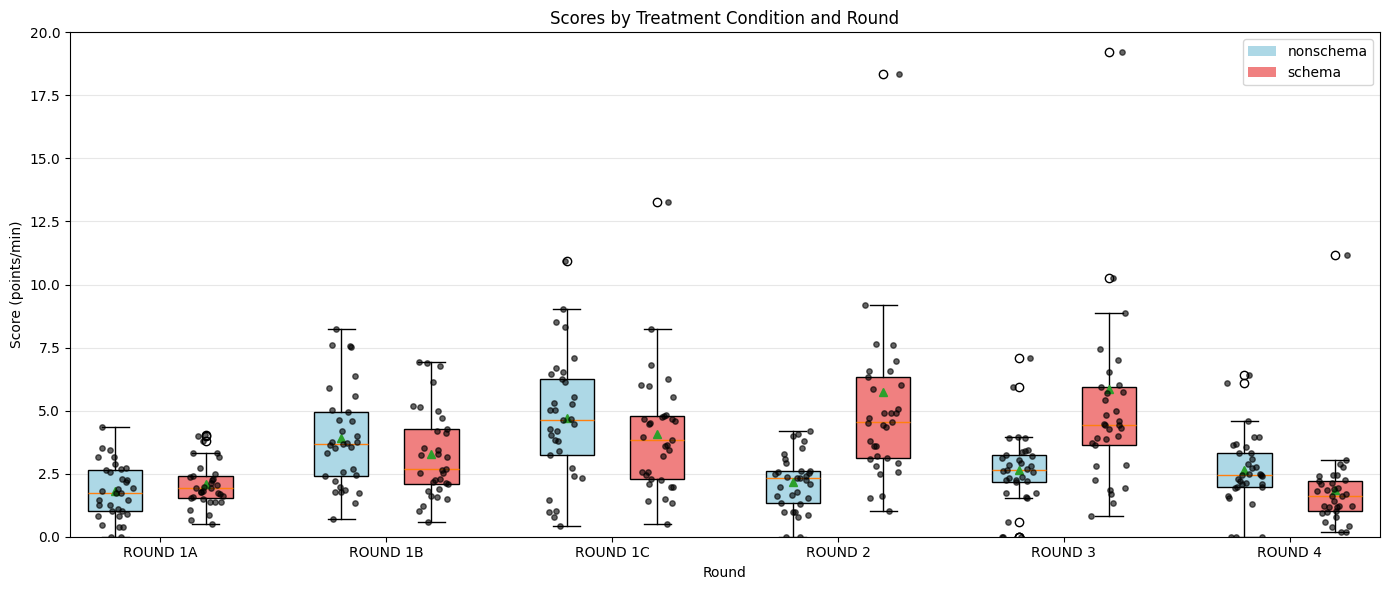

In [666]:
# [fig-score-box]
# Plot scores by round instead of labeling time
score_cols = [col for col in data.columns if col.startswith('score_')]



# Prepare data for box plot
plot_data = []
for col in score_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'score': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = score_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'score_1a' to 'Round 1a', etc.
    return col_name.replace('score_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['score'].dropna()
        box_data.append(data_subset)

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Round')
ax.set_ylabel('Score (points/min)')
ax.set_title('Scores by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# # Add n labels above each box
# n_counts = plot_df.groupby(['round', 'condition']).count()['score']
# for i, round_name in enumerate(rounds):
#     for j, condition in enumerate(conditions):
#         n = n_counts.get((round_name, condition), 0)
#         pos = i * (len(conditions) + 0.5) + j
#         y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
#         ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)

ax.set_ylim(0,20)

plt.tight_layout()
plt.show()

# Figures formatted for PNAS

Saved figures/figure1.pdf and figures/figure1.png


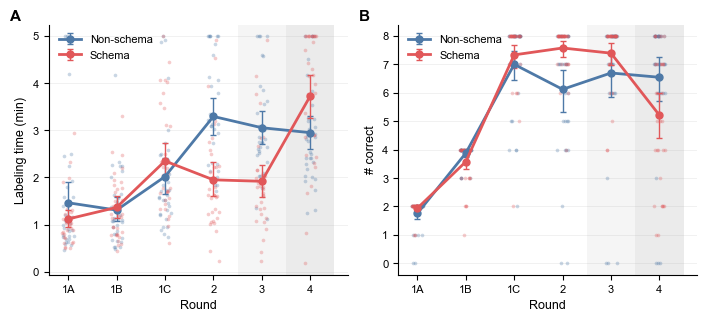


Fig. 1. Shared cognitive schemas accelerate coordination but impair adaptation under schema-destroying change.
(A) Labeling time and (B) accuracy (# correct) across all rounds for Schema (orange) and Non-schema (blue) groups.
Lines show condition means with 95% bootstrap-CI error bars; points show individual groups (jittered horizontally for clarity). Error-bar overlap is not a formal significance test (see Tables).
Rounds 1A–2 were condition-specific training rounds (Rounds 1A and 1B contained 2 and 4 images respectively; all other rounds contained 8).
Shaded background regions mark the preregistered test rounds: Round 3 introduced a schema-conserving environmental change (H1) and Round 4 introduced a schema-destroying change (H2).



In [667]:
# [fig-all-rounds]
# ── PNAS Figure 1 ──────────────────────────────────────────────────────────────
# Two-panel shaded area plot: labeling time (A) and accuracy (B) across all rounds
# Full page width (7.0 in). Styles applied locally via rc_context.

import os

def _boot_ci(x, n_boot=10000, seed=42):
    """95% percentile bootstrap CI of the mean (assumption-free; same method as Study 2)."""
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    bm = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(bm, [2.5, 97.5]); return x.mean(), lo, hi

pnas_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'patch.linewidth': 0.6,
}
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}   # Tableau blue / red
labels = {'nonschema': 'Non-schema', 'schema': 'Schema'}

time_cols   = [c for c in data.columns if c.startswith('time_labeling_')]
acc_cols = [c for c in data.columns if c.startswith('accuracy_')]
round_lbl   = lambda c: c.replace('time_labeling_', '').replace('accuracy_', '').upper()

np.random.seed(42)
with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))

    panels = [
        (axes[0], time_cols,   'Labeling time (min)',        True),
        (axes[1], acc_cols, '# correct',  False),
    ]

    for ax, cols, ylabel, is_time in panels:
        x = list(range(len(cols)))
        xlabels = [round_lbl(c) for c in cols]

        # Subtle shading: schema-conserving (R3) and schema-destroying (R4)
        ax.axvspan(3.5, 4.5, color='#f5f5f5', zorder=0, linewidth=0)
        ax.axvspan(4.5, 5.5, color='#ebebeb', zorder=0, linewidth=0)
        for condition in ['nonschema', 'schema']:
            cond = data[data['treatment'] == condition]
            means = [cond[c].mean() for c in cols]
            _ci   = [_boot_ci(cond[c].values) for c in cols]
            yerr_ = np.array([[m - lo for (m, lo, hi) in _ci],
                              [hi - m for (m, lo, hi) in _ci]])
            # IQR band disabled (dispersion shown by jittered points):
            # q25s  = [cond[c].quantile(0.25) for c in cols]
            # q75s  = [cond[c].quantile(0.75) for c in cols]

            # Raw jittered points
            for xi, col in enumerate(cols):
                vals = cond[col].dropna().values
                jitter = np.random.uniform(-0.12, 0.12, len(vals))
                ax.scatter(xi + jitter, vals, color=colors[condition],
                           alpha=0.3, s=7, zorder=2, linewidths=0)

            # ax.fill_between(x, q25s, q75s, alpha=0.18,
            #                 color=colors[condition], zorder=3)
            ax.errorbar(x, means, yerr=yerr_, marker='o', linewidth=2,
                        color=colors[condition], markersize=5,
                        label=labels[condition], zorder=4,
                        elinewidth=1, capsize=2, capthick=1)

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel('Round')
        ax.set_ylabel(ylabel)
        ax.legend(frameon=False, loc='upper left')
        ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if is_time:
            ax.set_yticks(range(0, 310, 60))
            ax.set_yticklabels(range(0, 6, 1))

    # Panel labels
    for ax, lbl in zip(axes, ['A', 'B']):
        ax.text(-0.13, 1.06, lbl, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

    plt.tight_layout(pad=0.8, w_pad=1.5)
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/figure1.pdf', bbox_inches='tight')
    plt.savefig('figures/figure1.png', dpi=300, bbox_inches='tight')
    print("Saved figures/figure1.pdf and figures/figure1.png")
    plt.show()


print("""
Fig. 1. Shared cognitive schemas accelerate coordination but impair adaptation under schema-destroying change.
(A) Labeling time and (B) accuracy (# correct) across all rounds for Schema (orange) and Non-schema (blue) groups.
Lines show condition means with 95% bootstrap-CI error bars; points show individual groups (jittered horizontally for clarity). Error-bar overlap is not a formal significance test (see Tables).
Rounds 1A–2 were condition-specific training rounds (Rounds 1A and 1B contained 2 and 4 images respectively; all other rounds contained 8).
Shaded background regions mark the preregistered test rounds: Round 3 introduced a schema-conserving environmental change (H1) and Round 4 introduced a schema-destroying change (H2).
""")

Saved figures/figure1_ci.* (error bars = 95% bootstrap CI of the mean)


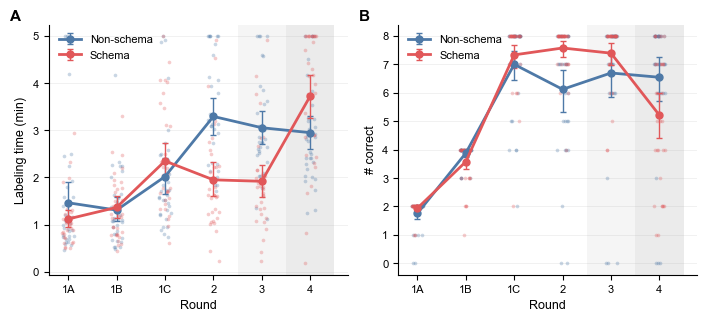

In [668]:
# [fig-all-rounds-ci]
# MOCKUP of [fig-all-rounds] with error bars = 95% bootstrap CI of the mean (percentile
# bootstrap, 10,000 resamples) instead of +/-1 SEM. Assumption-free, so it treats the
# right-skewed labeling time and the bounded 0-8 accuracy the same way, and matches the
# interval used in the Study 2 figure. Reuses pnas_style/colors/labels/*_cols from
# [fig-all-rounds] above. Saved to figures/figure1_ci.* (does not overwrite figure1).
import os

def _boot_ci(x, n_boot=10000, seed=42):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    bmeans = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(bmeans, [2.5, 97.5])
    return x.mean(), lo, hi

with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
    panels = [
        (axes[0], time_cols, 'Labeling time (min)', True),
        (axes[1], acc_cols,  '# correct',           False),
    ]
    np.random.seed(42)
    for ax, cols, ylabel, is_time in panels:
        x = list(range(len(cols)))
        xlabels = [round_lbl(c) for c in cols]
        ax.axvspan(3.5, 4.5, color='#f5f5f5', zorder=0, linewidth=0)
        ax.axvspan(4.5, 5.5, color='#ebebeb', zorder=0, linewidth=0)
        for condition in ['nonschema', 'schema']:
            cond = data[data['treatment'] == condition]
            ci = [_boot_ci(cond[c]) for c in cols]
            means = np.array([c[0] for c in ci])
            los   = np.array([c[1] for c in ci])
            his   = np.array([c[2] for c in ci])
            yerr  = np.vstack([means - los, his - means])
            for xi, col in enumerate(cols):
                vals = cond[col].dropna().values
                jitter = np.random.uniform(-0.12, 0.12, len(vals))
                ax.scatter(xi + jitter, vals, color=colors[condition],
                           alpha=0.3, s=7, zorder=2, linewidths=0)
            ax.errorbar(x, means, yerr=yerr, marker='o', linewidth=2,
                        color=colors[condition], markersize=5,
                        label=labels[condition], zorder=4,
                        elinewidth=1, capsize=2, capthick=1)
        ax.set_xticks(x); ax.set_xticklabels(xlabels)
        ax.set_xlabel('Round'); ax.set_ylabel(ylabel)
        ax.legend(frameon=False, loc='upper left')
        ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if is_time:
            ax.set_yticks(range(0, 310, 60)); ax.set_yticklabels(range(0, 6, 1))
    for ax, lbl in zip(axes, ['A', 'B']):
        ax.text(-0.13, 1.06, lbl, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')
    plt.tight_layout(pad=0.8, w_pad=1.5)
    os.makedirs('figures', exist_ok=True)
    pass  # figure1_ci retired: [fig-all-rounds] now uses 95% bootstrap CI, so this mockup no longer writes a separate file
    pass
    pass
    plt.show()


Saved figures/figure2.pdf and figures/figure2.png


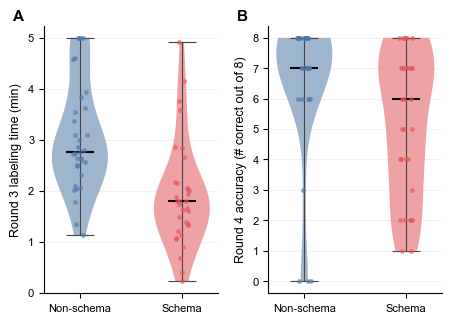


Fig. 2. Schema condition reduces labeling time under schema-conserving change but impairs accuracy under schema-destroying change.
(A) Round 3 labeling time (H1) and (B) Round 4 accuracy (H2) by condition.
Violins show the full distribution; horizontal lines show medians; points show individual groups (jittered horizontally for clarity).
H1 was tested with a one-tailed Welch’s t-test (Schema < Non-schema); H2 was tested with a one-tailed Mann–Whitney U test using a permutation-based p-value (Schema < Non-schema).



In [669]:
# [fig-pnas-2]
# ── PNAS Figure 2 ──────────────────────────────────────────────────────────────
# Two-panel hypothesis tests: R3 labeling time (A, H1) and R4 accuracy (B, H2)
# 1.5-column width (4.5 in). Styles applied locally via rc_context.

pnas_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.6,
}
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}   # Tableau blue / red
xlabels = ['Non-schema', 'Schema']

np.random.seed(42)
with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(1, 2, figsize=(4.5, 3.2))

    panels = [
        (axes[0], 'time_labeling_3', 'Round 3 labeling time (min)', True,  'A'),
        (axes[1], 'accuracy_4', 'Round 4 accuracy (# correct out of 8)', False, 'B'),
    ]

    for ax, col, ylabel, is_time, panel_lbl in panels:
        violin_data = [data[data['treatment'] == cond][col].dropna().values
                       for cond in ['nonschema', 'schema']]

        vp = ax.violinplot(violin_data, positions=[0, 1],
                           showmedians=True, showmeans=False, widths=0.55)

        # Style violin bodies
        for body, cond in zip(vp['bodies'], ['nonschema', 'schema']):
            body.set_facecolor(colors[cond])
            body.set_alpha(0.55)
            body.set_linewidth(0.6)
        vp['cmedians'].set_color('black')
        vp['cmedians'].set_linewidth(1.5)
        for part in ['cbars', 'cmins', 'cmaxes']:
            vp[part].set_color('#444444')
            vp[part].set_linewidth(0.8)

        # Jittered strip
        for i, cond in enumerate(['nonschema', 'schema']):
            vals = data[data['treatment'] == cond][col].dropna().values
            jitter = np.random.uniform(-0.07, 0.07, len(vals))
            ax.scatter(i + jitter, vals, color=colors[cond],
                       alpha=0.65, s=12, zorder=3, linewidths=0)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(xlabels)
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if is_time:
            ax.set_yticks(range(0, 310, 60))
            ax.set_yticklabels(range(0, 6, 1))

        ax.text(-0.18, 1.06, panel_lbl, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

    plt.tight_layout(pad=0.8, w_pad=1.5)
    plt.savefig('figures/figure2.pdf', dpi=600, bbox_inches='tight')
    plt.savefig('figures/figure2.png', dpi=600, bbox_inches='tight')
    print("Saved figures/figure2.pdf and figures/figure2.png")
    plt.show()

print("""
Fig. 2. Schema condition reduces labeling time under schema-conserving change but impairs accuracy under schema-destroying change.
(A) Round 3 labeling time (H1) and (B) Round 4 accuracy (H2) by condition.
Violins show the full distribution; horizontal lines show medians; points show individual groups (jittered horizontally for clarity).
H1 was tested with a one-tailed Welch\u2019s t-test (Schema < Non-schema); H2 was tested with a one-tailed Mann\u2013Whitney U test using a permutation-based p-value (Schema < Non-schema).
""")

In [670]:
# [table1-descriptives]
# ── Table 1: Descriptive statistics across all rounds ─────────────────────────
# Mean (SD) for labeling time (minutes) and accuracy (# correct) by condition and round.
# Column order: Schema Time, Non-schema Time, Schema Accuracy, Non-schema Accuracy

rounds = ['1a', '1b', '1c', '2', '3', '4']

rows = []
for r in rounds:
    row = {'Round': r.upper()}
    for metric, col_prefix, divisor in [('time', 'time_labeling', 60), ('accuracy', 'accuracy', 1)]:
        for cond, label in [('schema', 'Schema'), ('nonschema', 'Non-schema')]:
            cond_data = data[data['treatment'] == cond]
            vals = cond_data[f'{col_prefix}_{r}'].dropna() / divisor
            col_name = 'Time' if metric == 'time' else 'Accuracy'
            row[f'{col_name} {label}'] = f"{vals.mean():.2f} ({vals.std(ddof=1):.2f})"
    rows.append(row)

t1 = pd.DataFrame(rows).set_index('Round')[
    ['Time Schema', 'Time Non-schema', 'Accuracy Schema', 'Accuracy Non-schema']
]

print("Table 1. Labeling time (min) and accuracy (# correct) by condition and round.")
print("Values are mean (SD). Rounds 3 and 4 are the preregistered test rounds.")
print()
print(t1.to_string())

# ── Markdown ───────────────────────────────────────────────────────────────────
print("\n**Table 1.** Labeling time (min) and accuracy (# correct, 0\u20138) by condition and round. Values are mean (SD).\n")
print("| Round | Time Schema | Time Non-schema | Accuracy Schema | Accuracy Non-schema |")
print("|-------|-------------|-----------------|-----------------|---------------------|")
for r in rounds:
    row_vals = [r.upper()]
    for metric, col_prefix, divisor in [('time', 'time_labeling', 60), ('accuracy', 'accuracy', 1)]:
        for cond in ['schema', 'nonschema']:
            cond_data = data[data['treatment'] == cond]
            vals = cond_data[f'{col_prefix}_{r}'].dropna() / divisor
            row_vals.append(f"{vals.mean():.2f} ({vals.std(ddof=1):.2f})")
    print("| " + " | ".join(row_vals) + " |")


Table 1. Labeling time (min) and accuracy (# correct) by condition and round.
Values are mean (SD). Rounds 3 and 4 are the preregistered test rounds.

       Time Schema Time Non-schema Accuracy Schema Accuracy Non-schema
Round                                                                 
1A     1.12 (0.54)     1.46 (1.18)     1.94 (0.24)         1.76 (0.56)
1B     1.36 (0.67)     1.31 (0.77)     3.58 (0.79)         3.88 (0.33)
1C     2.35 (1.13)     2.02 (1.17)     7.33 (1.24)         7.00 (1.58)
2      1.95 (1.08)     3.29 (1.15)     7.58 (0.87)         6.12 (2.26)
3      1.92 (1.03)     3.05 (1.07)     7.39 (1.17)         6.70 (2.39)
4      3.72 (1.37)     2.95 (1.05)     5.21 (2.33)         6.55 (2.35)

**Table 1.** Labeling time (min) and accuracy (# correct, 0–8) by condition and round. Values are mean (SD).

| Round | Time Schema | Time Non-schema | Accuracy Schema | Accuracy Non-schema |
|-------|-------------|-----------------|-----------------|---------------------|
| 1A |

In [671]:
# [table2-hypothesis-tests]
# ── Table 2: Primary hypothesis test results ──────────────────────────────────
# Uses variables computed in H1, H2a, and H2b cells.
# H1: Welch's t-test on R3 labeling time (seconds → minutes here).
# H2a: Welch's t-test on ΔT (R4−R3 labeling time), difference-in-differences.
# H2b: Mann-Whitney U (permutation-based) on R4 accuracy.

import numpy as np

def fmt_p(p):  # report p to 3 dp; "< .001" below that threshold
    return "< .001" if p < .001 else f"{p:.3f}"


# ── H1: recompute CI with correct Welch-Satterthwaite df ──────────────────────
n1, n2 = len(schema_time3), len(nonschema_time3)
s1, s2 = schema_time3.var(ddof=1), nonschema_time3.var(ddof=1)
se_diff = np.sqrt(s1/n1 + s2/n2)
df_ws = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df=df_ws)
h1_ci_lo = (mean_diff - t_crit * se_diff) / 60
h1_ci_hi = (mean_diff + t_crit * se_diff) / 60
h1_diff_min = mean_diff / 60

# ── H2a: convert to minutes for table ─────────────────────────────────────────
h2a_diff_min = h2a_mean_diff / 60
h2a_ci_min = (h2a_ci[0] / 60, h2a_ci[1] / 60)

rows = [
    {
        'Hypothesis':    'H1: Round 3 labeling time',
        'Test':          "Welch's t",
        'Schema':        f"{schema_time3.mean()/60:.2f} ({schema_time3.std(ddof=1)/60:.2f})",
        'Non-schema':    f"{nonschema_time3.mean()/60:.2f} ({nonschema_time3.std(ddof=1)/60:.2f})",
        'Difference':    f"{h1_diff_min:.2f} [{h1_ci_lo:.2f}, {h1_ci_hi:.2f}]",
        'Effect size':   f"d = {cohens_d:.3f}",
        'Statistic':     f"t({df_ws:.1f}) = {t_stat:.3f}",
        'p (one-tailed)': fmt_p(p_val),
    },
    {
        'Hypothesis':    u'H2a: \u0394 labeling time (R4\u2212R3)',
        'Test':          "Welch's t",
        'Schema':        f"{schema_delta.mean()/60:.2f} ({schema_delta.std(ddof=1)/60:.2f})",
        'Non-schema':    f"{nonschema_delta.mean()/60:.2f} ({nonschema_delta.std(ddof=1)/60:.2f})",
        'Difference':    f"{h2a_diff_min:.2f} [{h2a_ci_min[0]:.2f}, {h2a_ci_min[1]:.2f}]",
        'Effect size':   f"d = {h2a_d:.3f}",
        'Statistic':     f"t({df_h2a:.1f}) = {h2a_t:.3f}",
        'p (one-tailed)': fmt_p(h2a_p),
    },
    {
        'Hypothesis':    'H2b: Round 4 accuracy',
        'Test':          u'Mann\u2013Whitney U\u2020',
        'Schema':        f"{schema_mean4:.2f} ({schema_points4.std(ddof=1):.2f}), mdn = {schema_median4:.1f}",
        'Non-schema':    f"{nonschema_mean4:.2f} ({nonschema_points4.std(ddof=1):.2f}), mdn = {nonschema_median4:.1f}",
        'Difference':    f"HL = {hl_estimate:.2f} [{hl_ci[0]:.2f}, {hl_ci[1]:.2f}]",
        'Effect size':   f"\u03b4 = {cliff_d:.3f}",
        'Statistic':     f"U = {observed_u:.1f}",
        'p (one-tailed)': fmt_p(p_perm),
    },
]

t2 = pd.DataFrame(rows).set_index('Hypothesis')

print("Table 2. Primary hypothesis test results.")
print("H1: values in minutes; difference = Schema - Non-schema mean (95% CI, Welch-Satterthwaite).")
print("H2a: values in minutes; difference = Schema - Non-schema mean change R3\u2192R4 (95% CI, Welch-Satterthwaite).")
print("H2b: values on 0-8 scale; difference = Hodges-Lehmann estimate (95% bootstrap CI).")
print("\u2020 Permutation-based p-value, 9,999 permutations, seed = 42.")
print()
print(t2.to_string())

# ── Markdown ───────────────────────────────────────────────────────────────────
print("\n**Table 2.** Primary hypothesis test results.\n")
print("| Hypothesis | Test | Schema | Non-schema | Difference | Effect size | Statistic | p |")
print("|------------|------|--------|------------|------------|-------------|-----------|---|")
for row in rows:
    vals = [
        row['Hypothesis'],
        row['Test'].replace(u'\u2020', '\u2020').replace(u'\u2013', '\u2013'),
        row['Schema'],
        row['Non-schema'],
        row['Difference'],
        row['Effect size'].replace(u'\u03b4', '\u03b4'),
        row['Statistic'],
        row['p (one-tailed)'],
    ]
    print("| " + " | ".join(vals) + " |")
print(u"\n\u2020 Permutation-based p-value, 9,999 permutations, seed = 42.")

Table 2. Primary hypothesis test results.
H1: values in minutes; difference = Schema - Non-schema mean (95% CI, Welch-Satterthwaite).
H2a: values in minutes; difference = Schema - Non-schema mean change R3→R4 (95% CI, Welch-Satterthwaite).
H2b: values on 0-8 scale; difference = Hodges-Lehmann estimate (95% bootstrap CI).
† Permutation-based p-value, 9,999 permutations, seed = 42.

                                         Test                  Schema              Non-schema                Difference Effect size         Statistic p (one-tailed)
Hypothesis                                                                                                                                                          
H1: Round 3 labeling time           Welch's t             1.92 (1.03)             3.05 (1.07)      -1.14 [-1.65, -0.62]  d = -1.080  t(63.9) = -4.387         < .001
H2a: Δ labeling time (R4−R3)        Welch's t             1.80 (1.54)            -0.10 (0.74)         1.91 [1.31, 2.51]  

In [672]:
# [r4-manual-review]
# Schema groups' Round 2-4 recall labels, for manual classification (33 groups).
# Labels within each row are sorted alphabetically so reused names cluster together
# (image order is NOT preserved). Writes study_1_r4_manual_review.csv with a blank
# `classification` column to fill in (adapted / recognized-inadequate / no-recognition).
_analyzed = all_data[all_data["gameId"].isin(data["gameId"])]
_sch = _analyzed[_analyzed["treatment"] == "schema"].sort_values(["gameId", "position"])

def _r(row, rnd): return [str(row.get(f"recall_{rnd}_{i}", "")).strip() for i in range(8)]
def _join(vals):
    nonblank = sorted(x for x in vals if x)
    blanks = ["·"] * sum(1 for x in vals if not x)
    return " | ".join(nonblank + blanks)

_rows = []
for gid in sorted(_sch["gameId"].unique()):
    g = _sch[_sch["gameId"] == gid]
    print(f"══════════ {gid} ══════════")
    for rnd in ["2", "3", "4"]:
        for _, row in g.iterrows():
            print(f"  R{rnd} p{row['position']}: {_join(_r(row, rnd))}")
    print()
    rec = {"gameId": gid}
    for rnd in ["2", "3", "4"]:
        for _, row in g.iterrows():
            rec[f"R{rnd}_p{row['position']}"] = _join(_r(row, rnd))
    rec["classification"] = ""   # fill: adapted / recognized-inadequate / no-recognition
    rec["notes"] = ""
    _rows.append(rec)

review = pd.DataFrame(_rows)
review.to_csv("study_1_r4_manual_review.csv", index=False)
print(f"Wrote study_1_r4_manual_review.csv ({len(review)} schema groups).")


══════════ 0HQTBM ══════════
  R2 p0: blue black yellow | blue red brown | blue red yellow | orange black brown | orange black yellow | orange red brown | orange red yellow | red black brown
  R2 p1: blue black brown | blue black yellow | blue red brown | blue red yellow | orange | orange black yellow | orange red brown | orange red yellow
  R3 p0: blue black brown | blue black yellow | blue red brown | blue red yellow | orange black brown | orange black yellow | orange red brown | orange red yellow
  R3 p1: blue black brown | blue black yellow | blue red brown | blue red yellow | orange black brown | orange black yellow | orange red brown | orange red yellow
  R4 p0: blue black yellow short | blue black yellow tall | blue black yellow tall | blue black yellow tall | orange red brown short | orange red brown short | orange red brown tall | orange red brown tall
  R4 p1: blue black yellow short | blue black yellow short | blue black yellow tall | blue black yellow tall | orange red brow

In [673]:
# [manual-review-labels]
# Per-group R2/R3/R4 recall labels (both partners) for manual coding, BOTH conditions.
# Labels sorted alphabetically within each row so reuse clusters; blanks shown as ·.
# Use for the R3 manipulation check: did Schema groups use a feature-based schema and
# Non-schema groups use holistic names? Writes study_1_manual_review.csv with a blank
# `uses_schema_r3` column (fill yes/no).
_an = all_data[all_data["gameId"].isin(data["gameId"])]

def _r(row, rnd): return [str(row.get(f"recall_{rnd}_{i}", "")).strip() for i in range(8)]
def _join(vals):
    nb = sorted(x for x in vals if x and x != "nan")
    bl = ["·"] * sum(1 for x in vals if (not x) or x == "nan")
    return " | ".join(nb + bl)

_rows = []
for tr in ["schema", "nonschema"]:
    sub = _an[_an["treatment"] == tr].sort_values(["gameId", "position"])
    print("#" * 70); print(f"# {tr.upper()} groups ({sub['gameId'].nunique()})"); print("#" * 70)
    for gid in sorted(sub["gameId"].unique()):
        g = sub[sub["gameId"] == gid]
        print(f"══════════ {gid} ══════════")
        for rnd in ["2", "3", "4"]:
            for _, row in g.iterrows():
                print(f"  R{rnd} p{row['position']}: {_join(_r(row, rnd))}")
        print()
        rec = {"treatment": tr, "gameId": gid}
        for rnd in ["2", "3", "4"]:
            for _, row in g.iterrows():
                rec[f"R{rnd}_p{row['position']}"] = _join(_r(row, rnd))
        rec["uses_schema_r3"] = ""   # fill: yes / no
        rec["notes"] = ""
        _rows.append(rec)

review = pd.DataFrame(_rows)
review.to_csv("study_1_manual_review.csv", index=False)
print(f"Wrote study_1_manual_review.csv ({len(review)} groups, both conditions).")


######################################################################
# SCHEMA groups (33)
######################################################################
══════════ 0HQTBM ══════════
  R2 p0: blue black yellow | blue red brown | blue red yellow | orange black brown | orange black yellow | orange red brown | orange red yellow | red black brown
  R2 p1: blue black brown | blue black yellow | blue red brown | blue red yellow | orange | orange black yellow | orange red brown | orange red yellow
  R3 p0: blue black brown | blue black yellow | blue red brown | blue red yellow | orange black brown | orange black yellow | orange red brown | orange red yellow
  R3 p1: blue black brown | blue black yellow | blue red brown | blue red yellow | orange black brown | orange black yellow | orange red brown | orange red yellow
  R4 p0: blue black yellow short | blue black yellow tall | blue black yellow tall | blue black yellow tall | orange red brown short | orange red brown short | orange re

In [674]:
# [manipulation check]
# did they use schemas or holistic names in round 3?
used_schema_3 = [
    # schema condition
    "0HQTBM", "1PHMY2", "30BS7N", "31GC47", "3MTPC9", "4C45AQ", "7123Y2", "7XZ4VH", 
    "82WGW1", "9NVFJX", "C16QEP", "E22RRE", "F5TT2F", "GQK8HG", "GSRN5T", "K1JA24",
    "KHZJM5", "PP2GEH", "PYZZRG", "Q15A59", "QVB21B", "TBM35H", "VF2XR4",
    "VT5G2M", "YTYFXS", "ZD373X", "3TBNWP", "6NJQAK", "6Y1ZWP", 

    # nonschema condition
    "0NJX16"
]

used_holistic_3 = [
    "CA1VF5", "SFQ0P4", "TY9XBR", 
    "QHTZ3N", # mostly used schema in r3, just not exclusively
    # nonschema condition
    "14RBNC", "3NZWFJ", "3XTW7A", "407XTD", "4GBFHG", "57ZQA5", "868SK9", "987DM5",
    "9TJB6Q", "A5SQN4", "E8T5Z5", "GQR2MR", "GYV382", "HCMSNR", "HQ8J1N", "KHQ8YT",
    "KPV70Z", "KX2FC8", "MARST6", "MBQ84F", "MD8EBA", "NFEW6M", "NPT449", "QE3M01",
    "QQKA1C", "R2C7TK", "R54G96", "SJME17", "V85HRK", "W8KCV6", "YSC5HR", "Z6FG46"
]

# assert no duplicates across all lists
assert len(set(used_holistic_3 + used_schema_3)) == len(used_holistic_3) + len(used_schema_3)
# print non-unique groups
non_unique = set(used_holistic_3) & set(used_schema_3)
if non_unique:
    print(f"Non-unique groups: {non_unique}")

# check that all groups in the review df are in one of the lists
for group in review["gameId"]:
    if group not in used_holistic_3 and group not in used_schema_3:
        print(f"Group {group} is in the review df but not in either list")



from scipy.stats import fisher_exact

# R3 naming per group (from the hand-coded lists above) + assigned condition
r3 = {g: "schema" for g in used_schema_3}
r3.update({g: "holistic" for g in used_holistic_3})
cond = dict(zip(data["gameId"], data["treatment"]))

# coverage sanity check
missing, extra = set(cond) - set(r3), set(r3) - set(cond)
if missing: print("WARNING: analyzed groups not coded:", sorted(missing))
if extra:   print("WARNING: coded groups not in analyzed sample:", sorted(extra))

mc = pd.DataFrame([{"gameId": g, "condition": cond[g], "r3_naming": r3[g]}
                   for g in cond if g in r3])

ct = pd.crosstab(mc["condition"], mc["r3_naming"])
print("Round-3 naming x condition:")
print(ct.to_string())

# adherence = R3 naming matched the assigned condition
intended = {"schema": "schema", "nonschema": "holistic"}
print("\nTreatment adherence (behaved as assigned):")
adhered = 0
for c in ["schema", "nonschema"]:
    sub = mc[mc["condition"] == c]
    k = (sub["r3_naming"] == intended[c]).sum()
    adhered += k
    print(f"  {c:10}: {k}/{len(sub)} ({100*k/len(sub):.0f}%)")
print(f"  overall   : {adhered}/{len(mc)} ({100*adhered/len(mc):.0f}%)")

# association test: does R3 naming depend on assigned condition?
OR, p = fisher_exact([[ct.loc["schema", "schema"],    ct.loc["schema", "holistic"]],
                      [ct.loc["nonschema", "schema"], ct.loc["nonschema", "holistic"]]])
print(f"\nFisher's exact (condition x R3 schema use): OR = {OR:.1f}, p = {p:.2e}")        

Round-3 naming x condition:
r3_naming  holistic  schema
condition                  
nonschema        32       1
schema            4      29

Treatment adherence (behaved as assigned):
  schema    : 29/33 (88%)
  nonschema : 32/33 (97%)
  overall   : 61/66 (92%)

Fisher's exact (condition x R3 schema use): OR = 232.0, p = 4.92e-13


In [675]:
# Did participants 
recognized = [
    "0HQTBM", "1PHMY2", "30BS7N", "31GC47", "3MTPC9", "4C45AQ", "7123Y2", "7XZ4VH", 
    "82WGW1", "9NVFJX", "C16QEP", "E22RRE", "F5TT2F", "GQK8HG", "GSRN5T", "K1JA24",
    "KHZJM5", "PP2GEH", "PYZZRG", "Q15A59", "QVB21B", "TBM35H", "VF2XR4",
    "VT5G2M", "YTYFXS", "ZD373X"
]

no_recognition = [
    "3TBNWP", "6NJQAK", "6Y1ZWP", 
]              

no_schema_in_3 = used_holistic_3 # these didn't reject a consistent schema from r2-3, because they didn't have one.
# [    
#     "CA1VF5", "SFQ0P4", "TY9XBR", "QHTZ3N"
# ]                  

print(f"Adapted: {len(recognized)}")
print(f"No recognition: {len(no_recognition)}")
print(f"No schema: {len(no_schema_in_3)}")
print(f"Total: {len(recognized) + len(no_recognition) + len(no_schema_in_3)}")
# assert no duplicates across all lists
assert len(set(recognized + no_recognition + no_schema_in_3)) == len(recognized) + len(no_recognition) + len(no_schema_in_3)
# assert that all groups in the review df are in one of the lists
for group in review["gameId"]:
    if group not in recognized and group not in no_recognition and group not in no_schema_in_3:
        print(f"Group {group} is in the review df but not in any of the recognized lists")


Adapted: 26
No recognition: 3
No schema: 36
Total: 65
Group 0NJX16 is in the review df but not in any of the recognized lists


In [676]:
holistic_4 = [
    "CA1VF5", "TY9XBR", 
    "VF2XR4",  # only on one label
    # nonschema
    "14RBNC", "3NZWFJ", "3XTW7A", "407XTD", "4GBFHG", "57ZQA5", "868SK9", "987DM5",
    "9TJB6Q", "A5SQN4", "E8T5Z5", "GQR2MR", "GYV382", "HCMSNR", "HQ8J1N", "KHQ8YT",
    "KPV70Z", "KX2FC8", "MARST6", "MBQ84F", "MD8EBA", "NFEW6M", "NPT449", "QE3M01",
    "QQKA1C", "R2C7TK", "R54G96", "SJME17", "V85HRK", "W8KCV6", "YSC5HR", "Z6FG46"
]

schema_4 = [


    "0HQTBM", "1PHMY2", "30BS7N", "31GC47", "3MTPC9", "3TBNWP", "4C45AQ", "6NJQAK", 
    "6Y1ZWP", "7123Y2", "7XZ4VH", "82WGW1", "9NVFJX", "C16QEP", "E22RRE", "F5TT2F", 
    "GQK8HG", "GSRN5T", "K1JA24",  "PP2GEH", "PYZZRG", "Q15A59", "QHTZ3N",
    "QVB21B", "SFQ0P4", "TBM35H", "VT5G2M", "YTYFXS", "ZD373X", "KHZJM5",
    
    # nonschema
    "0NJX16"

]
# assert no duplicates across all lists
assert len(set(holistic_4 + schema_4)) == len(holistic_4) + len(schema_4)
# print non-unique groups
non_unique = set(holistic_4) & set(schema_4)
if non_unique:
    print(f"Non-unique groups: {non_unique}")

# check that all groups in the review df are in one of the lists
for group in review["gameId"]:
    if group not in holistic_4 and group not in schema_4:
        print(f"Group {group} is in the review df but not in either list")




In [677]:
# [r4-generation-vs-memory]
# Decompose R4 failure into generation vs recall, using the discussion-stage labels
# (labeling_4 = names the group GENERATED) vs recall_4 (what each partner REPRODUCED).
# Objective counts only. Recall loss is further split into divergence (partners recalled
# different names) vs forgetting (a partner couldn't reproduce the names).
from collections import Counter
_an = all_data[all_data["gameId"].isin(data["gameId"])]
_sch = _an[_an["treatment"] == "schema"]

def _parse_lab(txt):
    if not isinstance(txt, str): return []
    out = []
    for ln in txt.splitlines():
        ln = ln.strip()
        if not ln: continue
        nm = (ln.split(":", 1)[1] if ":" in ln else ln).strip().lower()
        if nm: out.append(nm)
    return out
def _rc(row, r): return [str(row.get(f"recall_{r}_{i}", "")).strip().lower() for i in range(8)]

_rows = []
for gid, g in _sch.groupby("gameId"):
    gen = max((_parse_lab(r.get("labeling_4")) for _, r in g.iterrows()), key=len)
    gen_n, gen_distinct = len(gen), len(set(gen))
    _cnt = Counter(gen)
    reps = ", ".join(f"{k} ×{v}" for k, v in _cnt.most_common() if v > 1)
    recs = [_rc(r, "4") for _, r in g.iterrows()]
    self_distinct = [len(set(x for x in p if x)) for p in recs]
    dA, dB = (self_distinct + [0, 0])[:2]
    M = len(set(recs[0][i] for i in range(8)
                if len(recs) == 2 and recs[0][i] and recs[0][i] == recs[1][i])) if len(recs) == 2 else 0
    if gen_n < 6:                    cat = "not_assessable (no labeling)"
    elif gen_distinct < 8:           cat = "generation-limited"
    elif M >= 8:                     cat = "succeeded"
    elif min(dA, dB) >= 6:           cat = "recall: divergence"   # both kept names, disagreed
    else:                            cat = "recall: forgetting"   # a partner collapsed
    _rows.append({"gameId": gid, "gen_distinct": gen_distinct, "selfA": dA, "selfB": dB,
                  "matched_acc": M, "category": cat, "repeats": reps})

genmem = pd.DataFrame(_rows)
pd.set_option("display.max_colwidth", None)
print(genmem["category"].value_counts().to_string()); print(f"\nTotal: {len(genmem)} schema groups\n")
# print(genmem.sort_values(["category", "matched_acc"]).to_string(index=False))
print("\nNote: 'not_assessable' groups left labeling_4 blank (named only at recall),",
      "so generation can't be measured:", genmem.loc[genmem.category.str.startswith("not"), "gameId"].tolist())
genmem.to_csv("study_1_r4_generation_vs_memory.csv", index=False)
print("Wrote study_1_r4_generation_vs_memory.csv")
genmem.sort_values(["category", "matched_acc"])

category
recall: divergence              11
generation-limited              10
succeeded                        6
not_assessable (no labeling)     5
recall: forgetting               1

Total: 33 schema groups


Note: 'not_assessable' groups left labeling_4 blank (named only at recall), so generation can't be measured: ['6Y1ZWP', '7123Y2', 'PP2GEH', 'TBM35H', 'ZD373X']
Wrote study_1_r4_generation_vs_memory.csv


,gameId,gen_distinct,selfA,selfB,matched_acc,category,repeats
5,3TBNWP,2,2,2,2,generation-limited,"orange red brown ×4, purple black yellow ×4"
7,6NJQAK,3,2,3,2,generation-limited,"orange red brown ×4, purple black yellow ×3"
0,0HQTBM,4,4,4,4,generation-limited,"orange red brown tall ×3, blue black yellow short ×2, blue black yellow tall ×2"
1,1PHMY2,5,4,5,4,generation-limited,"orange left brown ×2, purple right yellow ×2, orange left brown long ×2"
2,30BS7N,7,6,5,4,generation-limited,purple right square ×2
19,K1JA24,6,6,6,5,generation-limited,"ol r b ×2, gr b y s ×2"
23,Q15A59,7,8,7,5,generation-limited,
18,GSRN5T,7,7,8,6,generation-limited,obrb ×2
4,3MTPC9,7,7,7,7,generation-limited,ryb ×2
25,QVB21B,7,7,7,7,generation-limited,lobrb ×2


In [678]:
# [r4-generation-test]
# Does the SCHEMA condition impair GENERATION of unique labels? DV = number of distinct
# labels each group produced for the 8 R4 images (bounded 0-8 count). Tested with the same
# nonparametric battery as the accuracy DV: one-tailed permutation Mann-Whitney
# (schema < nonschema), Hodges-Lehmann estimate (95% bootstrap CI), Cliff's delta.
#
# The test is reported under TWO ways of scoring "labels generated", because ~5 groups left
# the discussion-stage labeling box blank and typed names only at the recall stage:
#   * PRIMARY ("recall-fallback"): for those blank-labeling groups, count distinct labels
#     from their RECALL responses instead. A blank labeling box reflects WHERE a group chose
#     to write, not a failure to come up with names (e.g. TBM35H wrote nothing in the box but
#     produced 8 distinct names at recall); using recall avoids scoring them as zero-generation.
#   * ROBUSTNESS ("raw labeling"): score the labeling box at face value -> a blank box counts
#     as 0 distinct labels, no recoding.
# Groups that filled the labeling box (lab_n >= 6 names) are scored identically either way;
# only the ~5 blank-labeling groups differ. The schema < nonschema result holds under both,
# so it does not hinge on how the blank-labeling groups are treated.
np.random.seed(42)
_an = all_data[all_data["gameId"].isin(data["gameId"])]

def _parse_lab(txt):
    if not isinstance(txt, str): return []
    out = []
    for ln in txt.splitlines():
        ln = ln.strip()
        if not ln: continue
        nm = (ln.split(":", 1)[1] if ":" in ln else ln).strip().lower()
        if nm: out.append(nm)
    return out
def _rc(row, r): return [str(row.get(f"recall_{r}_{i}", "")).strip().lower() for i in range(8)]

def _gen_unique(g, fallback=True):
    labs = [_parse_lab(r.get("labeling_4")) for _, r in g.iterrows()]
    lab_distinct = max((len(set(x)) for x in labs), default=0)
    lab_n = max((len(x) for x in labs), default=0)
    if lab_n >= 6 or not fallback:
        return min(lab_distinct, 8)              # filled the labeling box -> count its distinct labels
    # blank labeling box (and fallback on): use the most distinct labels either partner gave at recall
    recs = [_rc(r, "4") for _, r in g.iterrows()]
    return min(max((len(set(x for x in p if x)) for p in recs), default=0), 8)

def _perm_mwu(a, b, alt="less", n_perm=9999, seed=42):
    u, _ = stats.mannwhitneyu(a, b, alternative=alt)
    pool = np.concatenate([a, b]); k = len(a); rng = np.random.default_rng(seed); e = 0
    for _ in range(n_perm):
        perm = rng.permutation(pool)
        if stats.mannwhitneyu(perm[:k], perm[k:], alternative=alt).statistic <= u:
            e += 1
    return u, (e + 1) / (n_perm + 1)
def _cliffs(x, y): return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (len(x) * len(y))

for _fb, _label in [(True, "primary: recall-fallback for blank labeling"),
                    (False, "robustness: raw labeling only")]:
    _vals = {tr: np.array([_gen_unique(g, _fb) for _, g in
                           _an[_an["treatment"] == tr].groupby("gameId")], float)
             for tr in ["schema", "nonschema"]}
    _s, _ns = _vals["schema"], _vals["nonschema"]
    _u, _p = _perm_mwu(_s, _ns, "less")
    _hl = np.median(_s[:, None] - _ns)
    _rng = np.random.default_rng(42)
    _boot = np.array([np.median(_rng.choice(_s, len(_s))[:, None] - _rng.choice(_ns, len(_ns)))
                      for _ in range(9999)])
    print("=" * 64)
    print(f"Unique labels generated in R4 ({_label})")
    print("=" * 64)
    print(f"  schema:    n={len(_s):3d}  mean={_s.mean():.2f}  median={np.median(_s):.1f}  sd={_s.std(ddof=1):.2f}")
    print(f"  nonschema: n={len(_ns):3d}  mean={_ns.mean():.2f}  median={np.median(_ns):.1f}  sd={_ns.std(ddof=1):.2f}")
    print(f"  Mann-Whitney U (one-tailed, schema<nonschema): U={_u:.1f}, perm p={_p:.4f}")
    print(f"  Hodges-Lehmann (schema-nonschema): {_hl:+.1f}  [95% boot CI {np.percentile(_boot,2.5):+.1f}, {np.percentile(_boot,97.5):+.1f}]")
    print(f"  Cliff's delta: {_cliffs(_s,_ns):+.3f}")
    print(f"  groups below 8 unique:  schema {int((_s<8).sum())}/{len(_s)},  nonschema {int((_ns<8).sum())}/{len(_ns)}")
    print()


Unique labels generated in R4 (primary: recall-fallback for blank labeling)
  schema:    n= 33  mean=6.82  median=8.0  sd=1.89
  nonschema: n= 33  mean=7.97  median=8.0  sd=0.17
  Mann-Whitney U (one-tailed, schema<nonschema): U=326.0, perm p=0.0002
  Hodges-Lehmann (schema-nonschema): +0.0  [95% boot CI -1.0, +0.0]
  Cliff's delta: -0.401
  groups below 8 unique:  schema 14/33,  nonschema 1/33

Unique labels generated in R4 (robustness: raw labeling only)
  schema:    n= 33  mean=6.09  median=8.0  sd=2.89
  nonschema: n= 33  mean=7.73  median=8.0  sd=1.40
  Mann-Whitney U (one-tailed, schema<nonschema): U=330.5, perm p=0.0003
  Hodges-Lehmann (schema-nonschema): +0.0  [95% boot CI -1.0, +0.0]
  Cliff's delta: -0.393
  groups below 8 unique:  schema 15/33,  nonschema 2/33



In [679]:
# [r4-accuracy-given-unique-generation]
# Among groups that produced 8 UNIQUE labels at the labeling stage, compare R4 accuracy
# by condition. Isolates recall-stage performance given successful generation: if schema
# and non-schema are comparable here, the schema's penalty lies upstream (at generation).
def _parse_lab(txt):
    if not isinstance(txt, str): return []
    out = []
    for ln in txt.splitlines():
        ln = ln.strip()
        if not ln: continue
        nm = (ln.split(":", 1)[1] if ":" in ln else ln).strip().lower()
        if nm: out.append(nm)
    return out

# per group: did the labeling stage yield >= 8 distinct names? (most-complete partner)
_lab = (all_data.groupby(["treatment", "gameId"])["labeling_4"]
        .apply(lambda s: max((len(set(_parse_lab(x))) for x in s), default=0))
        .rename("lab_distinct").reset_index())
_eight = _lab[_lab["lab_distinct"] >= 8][["treatment", "gameId"]]

acc8 = data.merge(_eight, on=["treatment", "gameId"], how="inner")
print("R4 accuracy among groups that generated 8 unique labels at the labeling stage:")
print(acc8.groupby("treatment")["accuracy_4"]
          .agg(n="count", mean="mean", sd=lambda x: x.std(ddof=1), median="median").round(2).to_string())

_a = acc8.loc[acc8["treatment"] == "schema", "accuracy_4"]
_b = acc8.loc[acc8["treatment"] == "nonschema", "accuracy_4"]
_u, _p = stats.mannwhitneyu(_a, _b, alternative="two-sided")
print(f"\nMann-Whitney U (two-sided): U={_u:.1f}, p={_p:.4f}")
print("Conditional on generating 8 unique labels, schema vs non-schema R4 accuracy is"
      + (" NOT" if _p >= 0.05 else "") + " significantly different.")


R4 accuracy among groups that generated 8 unique labels at the labeling stage:
            n  mean    sd  median
treatment                        
nonschema  31  6.71  2.08     7.0
schema     18  6.06  2.26     7.0

Mann-Whitney U (two-sided): U=230.0, p=0.2906
Conditional on generating 8 unique labels, schema vs non-schema R4 accuracy is NOT significantly different.


In [680]:
# [r4-match-vs-accuracy]
# Decompose the R4 schema accuracy deficit into coordination vs uniqueness. Per group,
# two measures from the R4 recall labels:
#   match    = # images where BOTH partners recalled the SAME label (uniqueness NOT required)
#              -> partner coordination
#   accuracy = # DISTINCT matched labels (the scored DV: matched AND unique)
# The gap (match - accuracy) is the "collision penalty" -- agreed labels that repeat across
# images. For non-schema, match == accuracy (labels are unique); for schema, match > accuracy.
def _rc(row, r): return [str(row.get(f"recall_{r}_{i}", "")).strip().lower() for i in range(8)]

_an = all_data[all_data["gameId"].isin(data["gameId"])]
_rows = []
for (gid, tr), g in _an.groupby(["gameId", "treatment"]):
    recs = [_rc(r, "4") for _, r in g.iterrows()]
    if len(recs) != 2:
        continue
    agreed = [recs[0][i] for i in range(8) if recs[0][i] and recs[0][i] == recs[1][i]]
    _rows.append({"treatment": tr, "gameId": gid, "match": len(agreed), "accuracy": len(set(agreed))})
mva = pd.DataFrame(_rows)
mva["collision_penalty"] = mva["match"] - mva["accuracy"]

def _cliffs(x, y): return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (len(x) * len(y))

print("R4: coordination (match) vs uniqueness (accuracy), by condition")
print("(match = both partners agree on a label; accuracy = matched AND unique)\n")
print(mva.groupby("treatment")[["match", "accuracy", "collision_penalty"]].mean().round(2).to_string())
print()
for col, name in [("match", "partner match rate (coordination; uniqueness dropped)"),
                  ("accuracy", "accuracy DV (matched & unique)")]:
    a = mva.loc[mva.treatment == "schema", col].values.astype(float)
    b = mva.loc[mva.treatment == "nonschema", col].values.astype(float)
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    print(f"  {name}:\n    schema {a.mean():.2f} vs nonschema {b.mean():.2f}  |  MWU U={u:.0f}, p={p:.4f}, Cliff's delta={_cliffs(a,b):+.3f}")
print("\nNon-schema match == accuracy (labels unique); schema match > accuracy, the gap being")
print("collisions. Coordination (match) does not differ significantly; the accuracy deficit is")
print("driven by non-unique labels -> a generation/uniqueness failure, not a recall/coordination one.")


R4: coordination (match) vs uniqueness (accuracy), by condition
(match = both partners agree on a label; accuracy = matched AND unique)

           match  accuracy  collision_penalty
treatment                                    
nonschema   6.55      6.55               0.00
schema      6.24      5.21               1.03

  partner match rate (coordination; uniqueness dropped):
    schema 6.24 vs nonschema 6.55  |  MWU U=458, p=0.2490, Cliff's delta=-0.159
  accuracy DV (matched & unique):
    schema 5.21 vs nonschema 6.55  |  MWU U=337, p=0.0064, Cliff's delta=-0.381

Non-schema match == accuracy (labels unique); schema match > accuracy, the gap being
collisions. Coordination (match) does not differ significantly; the accuracy deficit is
driven by non-unique labels -> a generation/uniqueness failure, not a recall/coordination one.


In [681]:
# [r4-accuracy-by-r4-schema-use]
# Descriptive: among schema-condition groups, R4 accuracy split by whether the group
# KEPT a schema vs ABANDONED it for holistic names in round 4 (hand-coded: schema_4 /
# holistic_4). Groups that dropped the schema score like the non-schema condition.
# NOTE: a post-hoc split on observed R4 behavior, not the randomized condition, and the
# holistic cell is tiny (n=3) -- read as mechanism illustration, not a causal contrast.
_sch4 = data[data["treatment"] == "schema"].copy()
_sch4["r4_use"] = _sch4["gameId"].map(
    lambda g: "kept schema" if g in schema_4 else ("abandoned (holistic)" if g in holistic_4 else "UNCLASSIFIED")
)
_unc = _sch4.loc[_sch4["r4_use"] == "UNCLASSIFIED", "gameId"].tolist()
if _unc:
    print(f"WARNING: groups not in schema_4/holistic_4: {_unc}")

print("R4 accuracy (0-8) by hand-coded R4 schema use (schema condition only):")
print(_sch4.groupby("r4_use")["accuracy_4"]
          .agg(n="count", mean="mean", sd=lambda x: x.std(ddof=1), median="median")
          .round(2).to_string())
print(f"\nReference -- non-schema condition R4 accuracy: "
      f"mean={data.loc[data.treatment=='nonschema','accuracy_4'].mean():.2f}, "
      f"median={data.loc[data.treatment=='nonschema','accuracy_4'].median():.1f}")


R4 accuracy (0-8) by hand-coded R4 schema use (schema condition only):
                       n  mean    sd  median
r4_use                                      
abandoned (holistic)   3  7.00  1.00     7.0
kept schema           30  5.03  2.36     5.0

Reference -- non-schema condition R4 accuracy: mean=6.55, median=7.0


# Secondary analysis (supplement): Study 2's exclusion rule applied to Study 1

Study 1's preregistered exclusion drops a participant only if they leave >25 of 38 recall items blank (pooled across rounds). Because that count includes the short warm-up rounds (R1a-1c = 14 items), it retains *mid-game dropouts* -- participants who finish the warm-up and then go silent for the analysis rounds (e.g. 0NJX16, 9TJB6Q, 3XTW7A, where one partner blanked all of R3/R4). Study 2 instead excludes a group if either partner leaves >2 blank in *any single* 8-item round, which catches these cases. Here we re-run Study 1's primary tests (H1, H2a, H2b) under Study 2's rule as a robustness check.

In [682]:
# [supp-study2-exclusions]
# Re-derive the Study 1 sample under STUDY 2's exclusion rule (>2 blanks in any single
# 8-item round: 1c/2/3/4) instead of Study 1's pooled rule (>25 of 38 blank), and re-run
# the primary tests. Self-contained (re-reads raw data; prefixes vars with _ to avoid
# clobbering notebook globals).
import glob, json as _json
np.random.seed(42)

_raw = []
for _fn in glob.glob("../data/study_1_schema_nonschema/batch_*.scienceData.jsonl"):
    for _line in open(_fn):
        _r = _json.loads(_line)
        if _r["sampleId"] != "missing":
            _raw.append(_r)

_df = pd.DataFrame({"treatment": [r["treatment"]["name"] for r in _raw],
                    "gameId": [r["gameId"][-6:] for r in _raw],
                    "num_reports": [len(r["reports"]) for r in _raw]})
_rcl = pd.DataFrame([{k: d["value"].lower().strip() for k, d in r["prompts"].items() if "recall" in k} for r in _raw])
_rcl.columns = [c.replace("prompt_recall_", "recall_") for c in _rcl.columns]
_rcl = _rcl[sorted(_rcl.columns)].fillna("")
_st = pd.DataFrame([{k: v["time"] for k, v in r["stageSubmissions"].items()} for r in _raw])
_st.columns = ["time_" + "_".join(c.replace("submitButton_", "").split("_")[-3:]) for c in _st.columns]
_ltc = [c for c in _st.columns if "labeling" in c]; _st[_ltc] = _st[_ltc].fillna(300)
_df = pd.concat([_df.reset_index(drop=True), _rcl.reset_index(drop=True), _st[_ltc].reset_index(drop=True)], axis=1)
_m = (_df.groupby("gameId")[_rcl.columns].nunique() == 1) & (_df.groupby("gameId")[_rcl.columns].count() == 2)
_m.columns = [c.replace("recall_", "match_") for c in _m.columns]
_df = pd.merge(_df, _m, left_on="gameId", right_index=True)
for _mc in [c for c in _df.columns if c.startswith("match_")]:
    _df[_mc.replace("match_", "matched_recall_")] = _df[_mc.replace("match_", "recall_")] * _df[_mc]
for _rd in ["3", "4"]:
    _cols = [c for c in _df.columns if f"matched_recall_{_rd}_" in c]
    _df[f"accuracy_{_rd}"] = _df[_cols].replace("", np.nan).nunique(axis=1).astype(float)

def _study2_blank(row):
    for _rd in ["1c", "2", "3", "4"]:                 # 8-item rounds; >2 blanks -> exclude
        _cs = [c for c in _rcl.columns if c.startswith(f"recall_{_rd}_")]
        if sum(row[c] == "" for c in _cs) > 2:
            return True
    return False

def _rerun(rule):
    x = _df[_df["num_reports"] < 3].copy()
    if rule == "study2":
        x = x[~x["gameId"].isin(x[x.apply(_study2_blank, axis=1)]["gameId"].unique())]
    else:
        x = x[(x[_rcl.columns] == "").sum(axis=1) < 26]
    _pc = (x.groupby("gameId")[["accuracy_3", "accuracy_4"]].count() == 2).all(axis=1)
    x = x[x["gameId"].isin(_pc[_pc].index)]
    x = x[~x["gameId"].isin(["ES0E4B", "RHNS8Z", "DA5DS8", "WMJTSY"])]
    x = x[x["treatment"].isin(["schema", "nonschema"])]
    g = x.groupby(["treatment", "gameId"], as_index=False)[["accuracy_4", "time_labeling_3", "time_labeling_4"]].max()
    s, n = g[g.treatment == "schema"], g[g.treatment == "nonschema"]
    t, p1 = stats.ttest_ind(s.time_labeling_3, n.time_labeling_3, equal_var=False, alternative="less")
    # H2a: attenuation of the labeling-time advantage, R3->R4 (difference-in-differences).
    # One-tailed Welch's t that Schema's deltaT (R4-R3) exceeds Non-schema's -- schema gets
    # relatively slower once the schema is broken. Mirrors the [h2a-time-attenuation] cell.
    sd = s.time_labeling_4.values - s.time_labeling_3.values
    nd = n.time_labeling_4.values - n.time_labeling_3.values
    h2a_t, h2a_p = stats.ttest_ind(sd, nd, equal_var=False, alternative="greater")
    # Companion direct test: R4 labeling time, Schema > Non-schema (one-tailed Welch's t).
    r4_t, r4_p = stats.ttest_ind(s.time_labeling_4, n.time_labeling_4, equal_var=False, alternative="greater")
    a, b = s.accuracy_4.values, n.accuracy_4.values
    u, _ = stats.mannwhitneyu(a, b, alternative="less")
    pool = np.concatenate([a, b]); k = len(a); rng = np.random.default_rng(42)
    perm = []
    for _ in range(9999):
        pp = rng.permutation(pool)
        perm.append(stats.mannwhitneyu(pp[:k], pp[k:], alternative="less").statistic)
    p2 = (np.sum(np.array(perm) <= u) + 1) / 10000
    cliff = (np.sum(a[:, np.newaxis] > b) - np.sum(a[:, np.newaxis] < b)) / (len(a) * len(b))
    print(f"  n: schema={len(s)}, nonschema={len(n)}")
    print(f"  H1  R3 labeling time:   schema {s.time_labeling_3.mean():.2f}s vs nonschema {n.time_labeling_3.mean():.2f}s  | Welch t={t:.2f}, one-tailed p={p1:.5f}")
    print(f"  H2a R3->R4 attenuation: schema deltaT {sd.mean():+.2f}s vs nonschema deltaT {nd.mean():+.2f}s  | Welch t={h2a_t:.2f}, one-tailed p={h2a_p:.5f}")
    print(f"      R4 labeling time:   schema {s.time_labeling_4.mean():.2f}s vs nonschema {n.time_labeling_4.mean():.2f}s  | Welch t={r4_t:.2f}, one-tailed (S>N) p={r4_p:.5f}")
    print(f"  H2b R4 accuracy:        schema {a.mean():.2f} vs nonschema {b.mean():.2f}  | MWU U={u:.0f}, perm p={p2:.4f}, HL={np.median(a[:, np.newaxis]-b):+.1f}, Cliff δ={cliff:+.3f}")

print("PRIMARY (preregistered: pooled >25/38 blank rule):")
_rerun("study1")
print("\nSECONDARY (Study 2 rule: >2 blanks in any single 8-item round):")
_rerun("study2")
print("\nAll three preregistered conclusions (H1, H2a, H2b) hold under Study 2's stricter rule.")
print("H2b (R4 accuracy) strengthens because Study 2's rule removes mid-game dropouts (mostly")
print("zero-scoring non-schema groups), raising the non-schema baseline; H1 and H2a are")
print("essentially unchanged, and the R4 labeling-time reversal (schema slower) also persists.")


PRIMARY (preregistered: pooled >25/38 blank rule):
  n: schema=33, nonschema=33
  H1  R3 labeling time:   schema 115.09s vs nonschema 183.25s  | Welch t=-4.39, one-tailed p=0.00002
  H2a R3->R4 attenuation: schema deltaT +108.28s vs nonschema deltaT -6.28s  | Welch t=6.44, one-tailed p=0.00000
      R4 labeling time:   schema 223.37s vs nonschema 176.96s  | Welch t=2.57, one-tailed (S>N) p=0.00633
  H2b R4 accuracy:        schema 5.21 vs nonschema 6.55  | MWU U=337, perm p=0.0025, HL=-1.0, Cliff δ=-0.381

SECONDARY (Study 2 rule: >2 blanks in any single 8-item round):
  n: schema=32, nonschema=29
  H1  R3 labeling time:   schema 114.94s vs nonschema 167.14s  | Welch t=-3.60, one-tailed p=0.00033
  H2a R3->R4 attenuation: schema deltaT +106.04s vs nonschema deltaT -3.15s  | Welch t=6.01, one-tailed p=0.00000
      R4 labeling time:   schema 220.98s vs nonschema 163.99s  | Welch t=3.25, one-tailed (S>N) p=0.00100
  H2b R4 accuracy:        schema 5.34 vs nonschema 7.21  | MWU U=228, perm 